# Сигнальный и ML-слой для трансграничных переводов

## От открытых курсов ЦБ до проверяемого сигнала

**Обзор:** этот ноутбук — самостоятельная версия всей основной работы по кейсу. Его можно загрузить в Kaggle вместе с `rates.csv` и выполнить сверху вниз.

Здесь мы:

1. загружаем и проверяем официальные курсы;
2. делаем EDA;
3. отдельно проверяем официальные девальвации и смены валютного режима;
4. строим простые сигналы без ML;
5. определяем, что такое «хороший момент»;
6. создаём признаки без информации из будущего;
7. сравниваем Logistic Regression, HistGradientBoosting и Extra Trees;
8. проверяем модели методом walk-forward;
9. учитываем асимметричную цену ошибки;
10. формируем финальную таблицу сигналов и локальное объяснение;
11. запускаем проверки на утечку будущего.

Главный принцип: **сигнал на дату T использует только то, что было доступно на дату T**.

## 0. Сначала фиксируем экономический смысл

Важно различать минимум и максимум курса.

ЦБ публикует курс в представлении:

```text
рублей за одну единицу валюты получателя
```

Например:

- `1 TJS = 8,50 RUB` — сомони дороже;
- `1 TJS = 8,00 RUB` — сомони дешевле, клиент получит больше сомони за те же рубли.

Поэтому в техническом ряду мы ищем **минимум RUB за валюту**, но для клиента это **максимум валюты получателя за один рубль**. Это один и тот же выгодный момент, просто курс записан с разных сторон.

## 1. Библиотеки и настройки

Используемые библиотеки: `pandas` работает с таблицами, `numpy` — с числами, `matplotlib/seaborn` рисуют графики, а `scikit-learn` содержит модели.

Праздничные признаки строятся пакетом `holidays`. Если его нет в среде Kaggle, ячейка установит его автоматически. Для полностью офлайн-запуска можно заранее добавить пакет или убрать календарные признаки.

In [1]:
import importlib.util
import json
import math
import random
import subprocess
import sys
import urllib.parse
import urllib.request
import xml.etree.ElementTree as ET
from bisect import bisect_right
from pathlib import Path

if importlib.util.find_spec("holidays") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "holidays"])

import holidays
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
print("Среда готова")

Среда готова


## 2. Конфигурация эксперимента

Здесь собраны все основные предположения — чтобы на QA-сессии можно было честно показать, что именно мы выбрали сами.

- горизонт — 5 следующих публикаций;
- допустимое отклонение от локального минимума — 25 б.п. = 0,25%;
- ложный пуш в 4 раза дороже пропущенного момента;
- после сигнала пропускаем одно обновление;
- после подтверждённого официального валютного разрыва не отправляем пуш 5 обновлений;
- модель должна давать управляемую частоту, а не писать каждый день.

In [2]:
RECIPIENT_CURRENCIES = ("TJS", "UZS", "KGS", "AMD", "KZT")
CONTEXT_CURRENCIES = ("USD", "EUR", "CNY")
ALL_CURRENCIES = RECIPIENT_CURRENCIES + CONTEXT_CURRENCIES

HORIZON = 5
TOLERANCE_BPS = 25
FALSE_POSITIVE_COST = 4.0
COOLDOWN_UPDATES = 1
MIN_WEEKLY_RATE = 1.4
STRONG_MARGIN = 0.15
POLICY_EVENT_QUARANTINE = HORIZON

CBR_CURRENCY_IDS = {
    "TJS": "R01670", "UZS": "R01717", "KGS": "R01370", "AMD": "R01060",
    "KZT": "R01335", "USD": "R01235", "EUR": "R01239", "CNY": "R01375",
}
CORRIDOR_COUNTRIES = {"TJS": "TJ", "UZS": "UZ", "KGS": "KG", "AMD": "AM", "KZT": "KZ"}

CONFIG = {
    "horizon_publications": HORIZON,
    "tolerance_bps": TOLERANCE_BPS,
    "false_positive_cost": FALSE_POSITIVE_COST,
    "cooldown_updates": COOLDOWN_UPDATES,
    "strong_margin": STRONG_MARGIN,
}
CONFIG

{'horizon_publications': 5,
 'tolerance_bps': 25,
 'false_positive_cost': 4.0,
 'cooldown_updates': 1,
 'strong_margin': 0.15}

## 3. Загрузка данных

**Рекомендуемый путь для Kaggle:** создать Dataset из файла `rates.csv` и прикрепить его к ноутбуку через **Add Input**. Код сам найдёт файл внутри `/kaggle/input`.

Если файла нет, предусмотрена воспроизводимая загрузка официальных XML ЦБ РФ. История скачивается кусками по несколько лет, номинал нормируется:

```text
rub_per_unit = опубликованное значение / номинал
```

Мы консервативно считаем курс доступным с даты действия. Точное историческое время публикации XML не содержит.

In [3]:
def parse_number(text):
    return float(str(text).strip().replace(" ", "").replace(",", "."))


def download_currency(currency, start="2010-01-01", end="2026-08-29"):
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)
    rows = []
    chunk_start = start
    while chunk_start <= end:
        chunk_end = min(pd.Timestamp(f"{chunk_start.year + 2}-12-31"), end)
        params = urllib.parse.urlencode({
            "date_req1": chunk_start.strftime("%d/%m/%Y"),
            "date_req2": chunk_end.strftime("%d/%m/%Y"),
            "VAL_NM_RQ": CBR_CURRENCY_IDS[currency],
        })
        url = f"https://www.cbr.ru/scripts/XML_dynamic.asp?{params}"
        request = urllib.request.Request(url, headers={"User-Agent": "fx-signal-kaggle/1.0"})
        with urllib.request.urlopen(request, timeout=120) as response:
            root = ET.fromstring(response.read())
        for node in root.findall("Record"):
            current_date = pd.to_datetime(node.attrib["Date"], format="%d.%m.%Y")
            nominal = int(parse_number(node.findtext("Nominal", "1")))
            value_rub = parse_number(node.findtext("Value", "0"))
            rows.append({
                "effective_date": current_date,
                "available_date": current_date,
                "currency": currency,
                "corridor": f"RUB_{currency}",
                "nominal": nominal,
                "value_rub": value_rub,
                "rub_per_unit": value_rub / nominal,
            })
        chunk_start = pd.Timestamp(f"{chunk_end.year + 1}-01-01")
    return pd.DataFrame(rows).drop_duplicates(["available_date", "currency"])


def find_rates_file():
    candidates = []
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        candidates.extend(kaggle_input.rglob("rates.csv"))
    candidates.extend([Path("rates.csv"), Path("data/rates.csv"), Path("../data/rates.csv")])
    return next((path for path in candidates if path.exists()), None)


def load_rates():
    path = find_rates_file()
    if path is not None:
        print(f"Читаем готовую выгрузку: {path}")
        return pd.read_csv(path, parse_dates=["effective_date", "available_date"])

    print("rates.csv не найден — скачиваем открытые ряды ЦБ РФ")
    parts = [download_currency(currency) for currency in ALL_CURRENCIES]
    result = pd.concat(parts, ignore_index=True)
    output = Path("/kaggle/working/rates.csv") if Path("/kaggle/working").exists() else Path("rates.csv")
    result.to_csv(output, index=False)
    print(f"Сохранено: {output}")
    return result


rates = load_rates().sort_values(["currency", "available_date"]).reset_index(drop=True)
rates["corridor"] = "RUB_" + rates["currency"]
rates.head()

Читаем готовую выгрузку: data/rates.csv


,effective_date,available_date,currency,corridor,nominal,value_rub,rub_per_unit
0,2010-01-12,2010-01-12,AMD,RUB_AMD,1000,77.9042,0.077904
1,2010-01-13,2010-01-13,AMD,RUB_AMD,1000,77.8209,0.077821
2,2010-01-14,2010-01-14,AMD,RUB_AMD,1000,78.4670,0.078467
3,2010-01-15,2010-01-15,AMD,RUB_AMD,1000,77.9600,0.077960
4,2010-01-16,2010-01-16,AMD,RUB_AMD,1000,78.2536,0.078254


## 4. Проверка качества данных

Перед построением ML-моделей проверяем качество данных:

- правильно ли нормирован номинал;
- нет ли дублей по валюте и дате;
- нет ли нулевых или отрицательных курсов;
- одинаково ли покрыты валюты;
- не превратили ли мы выходные в фиктивные нулевые движения.

Если здесь ошибка, дальше модель будет очень умно изучать неправильные данные.

In [4]:
rates["normalization_error"] = (rates["value_rub"] / rates["nominal"] - rates["rub_per_unit"]).abs()

quality = (
    rates.groupby("currency")
    .agg(
        observations=("available_date", "size"),
        start=("available_date", "min"),
        end=("available_date", "max"),
        unique_dates=("available_date", "nunique"),
        min_rate=("rub_per_unit", "min"),
        max_rate=("rub_per_unit", "max"),
        max_normalization_error=("normalization_error", "max"),
    )
    .reset_index()
)
quality["duplicate_dates"] = quality["observations"] - quality["unique_dates"]

display(Markdown(
    f"**Результаты:** {len(rates):,} строк, "
    f"период {rates.available_date.min().date()} — {rates.available_date.max().date()}, "
    f"валютных рядов: {rates.currency.nunique()}."
))
display(quality)

**Результаты:** 32,916 строк, период 2010-01-01 — 2026-08-29, валютных рядов: 8.

,currency,observations,start,end,unique_dates,min_rate,max_rate,max_normalization_error,duplicate_dates
0,AMD,4114,2010-01-12,2026-08-29,4114,0.071799,0.278846,9.714451e-17,0
1,CNY,4115,2010-01-01,2026-08-29,4115,4.197720,19.041500,1.776357e-15,0
2,EUR,4115,2010-01-01,2026-08-29,4115,37.420600,132.958100,0.000000e+00,0
3,KGS,4114,2010-01-12,2026-08-29,4114,0.584369,1.262420,2.220446e-16,0
4,KZT,4115,2010-01-01,2026-08-29,4115,0.112176,0.377368,9.714451e-17,0
5,TJS,4114,2010-01-12,2026-08-29,4114,4.729820,12.965000,1.776357e-15,0
6,USD,4115,2010-01-01,2026-08-29,4115,27.262500,120.378500,0.000000e+00,0
7,UZS,4114,2010-01-12,2026-08-29,4114,0.004737,0.029822,9.974660e-17,0


## 5. EDA: что происходит с курсами

Абсолютные уровни валют сравнивать нельзя: один сомони и один сум стоят по-разному. Поэтому каждый ряд приводим к индексу 100 на первой дате.

Если индекс растёт — валюта получателя дорожает в рублях. Если падает — за те же рубли клиент может получить больше валюты.

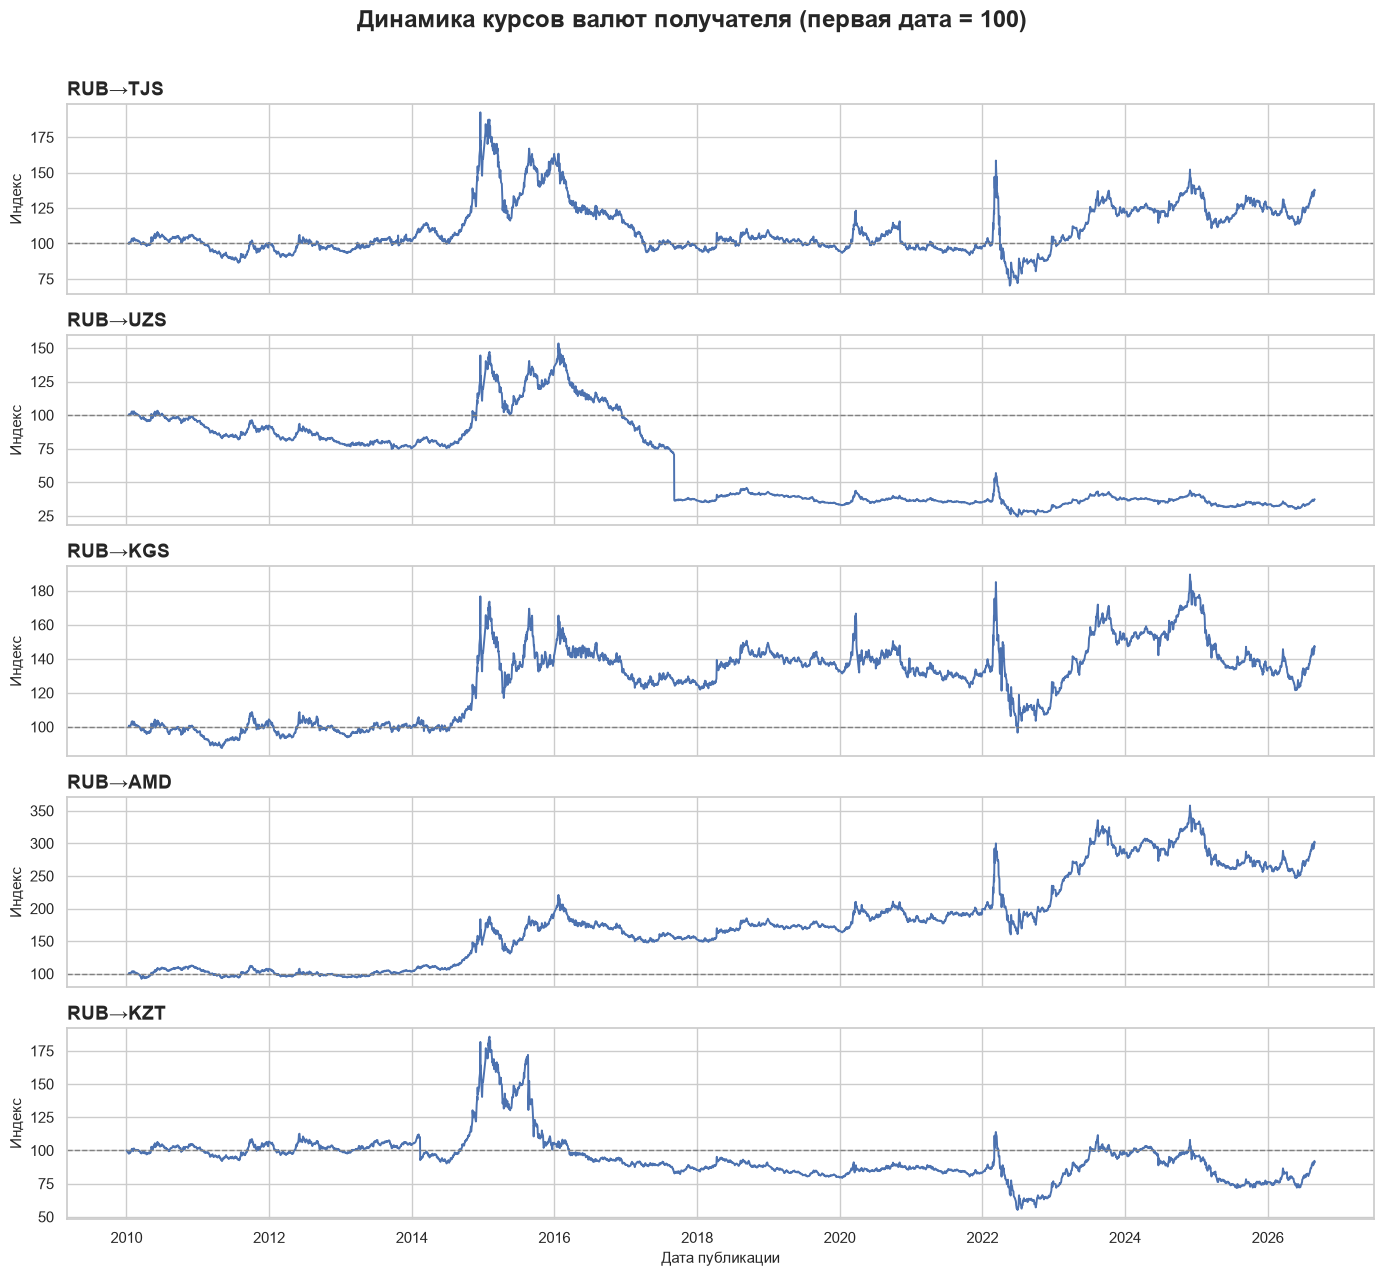

In [5]:
recipients = rates[rates.currency.isin(RECIPIENT_CURRENCIES)].copy()
recipients["index_100"] = recipients.groupby("currency")["rub_per_unit"].transform(lambda s: s / s.iloc[0] * 100)

fig, axes = plt.subplots(5, 1, figsize=(14, 13), sharex=True)
for ax, currency in zip(axes, RECIPIENT_CURRENCIES):
    current = recipients[recipients.currency == currency]
    ax.plot(current.available_date, current.index_100, linewidth=1.4)
    ax.axhline(100, color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"RUB→{currency}", loc="left", fontweight="bold")
    ax.set_ylabel("Индекс")
axes[-1].set_xlabel("Дата публикации")
fig.suptitle("Динамика курсов валют получателя (первая дата = 100)", fontsize=17, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

,median,p95,p99
currency,,,
TJS,0.458,2.361,5.031
UZS,0.467,2.180,4.402
KGS,0.455,2.302,4.755
AMD,0.465,2.154,4.189
KZT,0.422,2.100,4.252


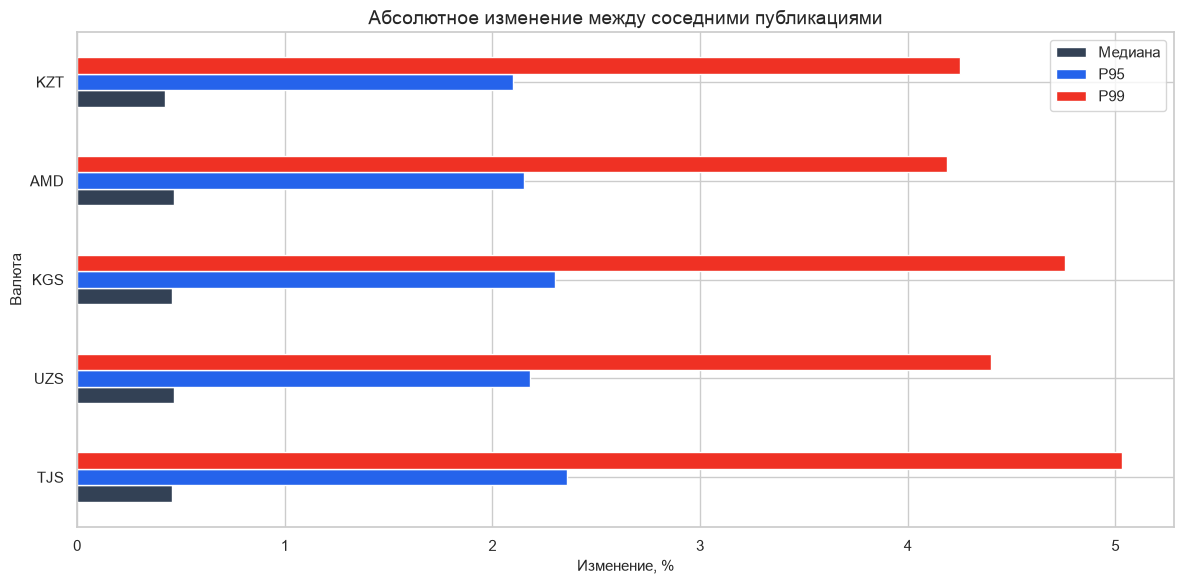

In [6]:
rates["return_pct"] = rates.groupby("currency")["rub_per_unit"].pct_change() * 100
return_stats = (
    rates[rates.currency.isin(RECIPIENT_CURRENCIES)]
    .assign(abs_return=lambda x: x.return_pct.abs())
    .groupby("currency")["abs_return"]
    .quantile([0.50, 0.95, 0.99])
    .unstack()
    .rename(columns={0.50: "median", 0.95: "p95", 0.99: "p99"})
    .reindex(RECIPIENT_CURRENCIES)
)
display(return_stats.round(3))

return_stats.plot(kind="barh", figsize=(12, 6), color=["#334155", "#2563EB", "#EF3124"])
plt.title("Абсолютное изменение между соседними публикациями")
plt.xlabel("Изменение, %")
plt.ylabel("Валюта")
plt.legend(["Медиана", "P95", "P99"])
plt.tight_layout()
plt.show()

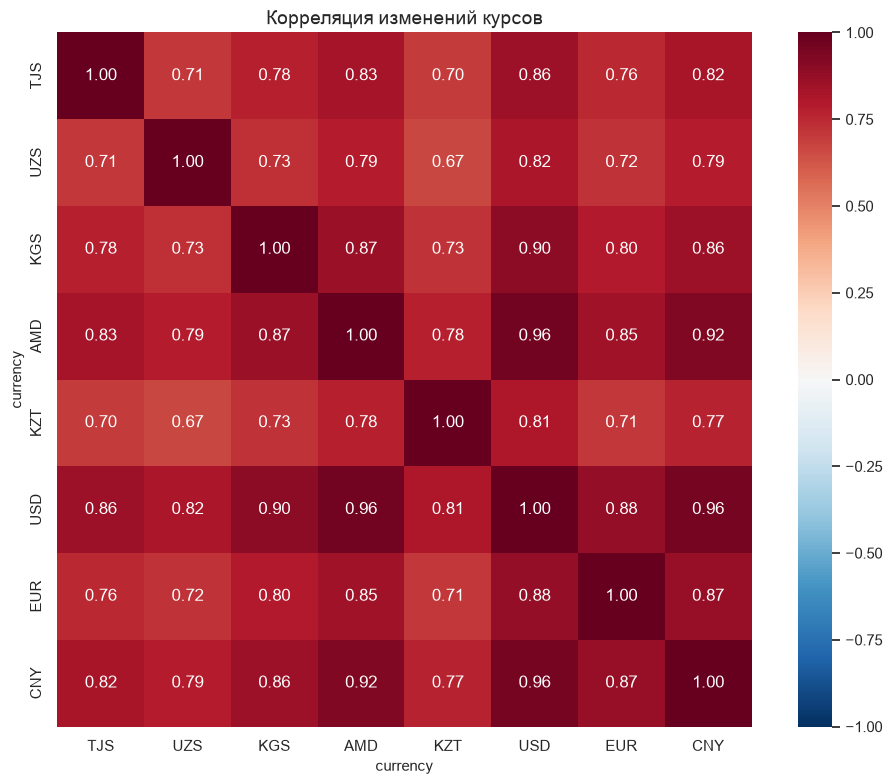

**Наблюдения:** валюты сильно связаны через общий рублёвый фактор. Поэтому USD, EUR и CNY полезно оставить как контекст, но случайно перемешивать даты нельзя.

In [7]:
return_panel = (
    rates.pivot(index="available_date", columns="currency", values="rub_per_unit")
    .sort_index()
    .pct_change(fill_method=None)
)
correlation = return_panel[list(ALL_CURRENCIES)].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True)
plt.title("Корреляция изменений курсов")
plt.tight_layout()
plt.show()

display(Markdown(
    "**Наблюдения:** валюты сильно связаны через общий рублёвый фактор. "
    "Поэтому USD, EUR и CNY полезно оставить как контекст, но случайно перемешивать даты нельзя."
))

## 5.1. Официальные девальвации и смены валютного режима

Здесь мы отделяем обычное рыночное ослабление валюты от решения государства или центрального банка. В нашей истории подтверждены три режимных события:

- **KZT, 11.02.2014:** Национальный банк Казахстана изменил валютный коридор; IMF оценивает девальвацию примерно в 18%. [Источник NBK](https://nationalbank.kz/file/download/64198), [источник IMF](https://www.imf.org/external/pubs/ft/scr/2014/cr14242.pdf).
- **KZT, 20.08.2015:** Казахстан перешёл к свободно плавающему курсу. Это смена режима, после которой тенге резко ослаб, а не обычный повторяемый сигнал. [Источник NBK](https://nationalbank.kz/file/download/1021).
- **UZS, 05.09.2017:** Узбекистан унифицировал официальный и параллельный курсы; официальный курс изменился примерно с 4 250 до 8 100 сумов за доллар. [Источник ЦБ Узбекистана](https://cbu.uz/ru/press_center/releases/38929/), [источник IMF](https://www.imf.org/en/news/articles/2018/03/14/ms031418-uzbekistan-staff-concluding-statement-of-the-2018-article-iv-mission).

Для AMD, KGS и TJS в выборке были периоды сильного рыночного ослабления, но мы не нашли сопоставимого подтверждённого одномоментного официального решения. Поэтому не называем любой скачок «официальной девальвацией».

Важная защита от утечки: событие становится доступно фильтру только с даты официального решения. После него мы ставим **карантин на дату события и следующие 5 публикаций**. Модель продолжает считать вероятность, но автоматический пуш не отправляется — сначала рынок должен переварить смену режима.

In [8]:
POLICY_EVENTS = pd.DataFrame([
    {
        "currency": "KZT", "corridor": "RUB_KZT", "event_date": "2014-02-11",
        "event_type": "official_devaluation", "documented_change_pct": -18.0,
        "description": "Изменение валютного коридора",
    },
    {
        "currency": "KZT", "corridor": "RUB_KZT", "event_date": "2015-08-20",
        "event_type": "regime_shift", "documented_change_pct": -45.0,
        "description": "Переход к свободно плавающему курсу",
    },
    {
        "currency": "UZS", "corridor": "RUB_UZS", "event_date": "2017-09-05",
        "event_type": "exchange_rate_unification", "documented_change_pct": -50.0,
        "description": "Унификация официального и параллельного курсов",
    },
])
POLICY_EVENTS["event_date"] = pd.to_datetime(POLICY_EVENTS["event_date"])


def policy_event_eligibility(corridor, quote_dates, quarantine_updates=POLICY_EVENT_QUARANTINE):
    dates = pd.DatetimeIndex(pd.to_datetime(quote_dates))
    eligible = np.ones(len(dates), dtype=bool)
    for event_date in POLICY_EVENTS.loc[
        POLICY_EVENTS.corridor == corridor, "event_date"
    ]:
        start = int(dates.searchsorted(event_date, side="left"))
        if start >= len(dates):
            continue
        if start == 0 and event_date < dates[0] and (dates[0] - event_date).days > 30:
            continue
        eligible[start:min(start + quarantine_updates + 1, len(dates))] = False
    return eligible


usd_quotes = (
    rates[rates.currency == "USD"][["available_date", "rub_per_unit"]]
    .rename(columns={"rub_per_unit": "rub_per_usd"})
    .sort_values("available_date")
)
event_rows = []
for event in POLICY_EVENTS.itertuples(index=False):
    current = rates[rates.currency == event.currency][
        ["available_date", "rub_per_unit"]
    ].sort_values("available_date")
    current = pd.merge_asof(current, usd_quotes, on="available_date", direction="backward")
    current["local_value_in_usd"] = current.rub_per_unit / current.rub_per_usd
    current["recipient_vs_usd_move_pct"] = current.local_value_in_usd.pct_change() * 100
    current["rub_quote_move_pct"] = current.rub_per_unit.pct_change() * 100

    start = int(current.available_date.searchsorted(event.event_date, side="left"))
    search_window = current.iloc[start:min(start + 3, len(current))]
    observed_index = search_window.recipient_vs_usd_move_pct.idxmin()
    observed = current.loc[observed_index]
    event_rows.append({
        "currency": event.currency,
        "official_event_date": event.event_date.date(),
        "largest_move_visible_on": observed.available_date.date(),
        "event_type": event.event_type,
        "documented_change_pct": event.documented_change_pct,
        "move_vs_usd_in_our_data_pct": observed.recipient_vs_usd_move_pct,
        "move_in_rub_quote_pct": observed.rub_quote_move_pct,
    })

event_study = pd.DataFrame(event_rows)
display(event_study.round(2))
display(Markdown(
    "**Результат:** в нашей выгрузке разрывы действительно огромные — "
    "это не обычная дневная волатильность. Дата максимального движения иногда идёт после "
    "официальной даты, потому что решение попадает в курс ЦБ на следующей публикации."
))

,currency,official_event_date,largest_move_visible_on,event_type,documented_change_pct,move_vs_usd_in_our_data_pct,move_in_rub_quote_pct
0,KZT,2014-02-11,2014-02-13,official_devaluation,-18.0,-15.71,-15.80
1,KZT,2015-08-20,2015-08-21,regime_shift,-45.0,-22.01,-20.54
2,UZS,2017-09-05,2017-09-06,exchange_rate_unification,-50.0,-48.02,-47.96


**Результат:** в нашей выгрузке разрывы действительно огромные — это не обычная дневная волатильность. Дата максимального движения иногда идёт после официальной даты, потому что решение попадает в курс ЦБ на следующей публикации.

## 6. Сначала сигналы без ML

Первая версия решения действительно была без машинного обучения. Мы сами формулировали правила:

- **level** — курс находится в нижних 20% последних 60 публикаций;
- **momentum** — курс снижается три публикации подряд;
- **stability** — курс низкий, продолжает снижаться, но последнее движение уже небольшое;
- **reversal** — курс был у минимума и начал от него расти: выгодное окно может закрываться.

Здесь ничего не обучается. Это человеческие гипотезы, которые мы обязаны проверить на истории. Их польза — понятность и честный baseline для ML.

И ещё один важный момент: сообщения проверяются по-разному. Для `level/momentum/stability` проверяем, что после пуша курс не стал заметно выгоднее. Для `reversal` проверяем, что курс действительно продолжил расти — то есть окно действительно закрывалось.

In [9]:
def trailing_rank(series, window):
    return series.rolling(window).apply(lambda values: np.mean(values <= values[-1]), raw=True)


def add_historical_target(frame, horizon=HORIZON, tolerance_bps=TOLERANCE_BPS):
    result = frame.copy()
    window = 2 * horizon + 1
    local_min = result.rub_per_unit.rolling(window, center=True).min()
    local_mean = result.rub_per_unit.rolling(window, center=True).mean()
    result["target"] = (result.rub_per_unit <= local_min * (1 + tolerance_bps / 10_000)).where(local_min.notna())
    result["benefit_bps"] = (local_mean / result.rub_per_unit - 1) * 10_000

    future = pd.concat(
        [result.rub_per_unit.shift(-step) for step in range(1, horizon + 1)], axis=1
    )
    complete_future = future.notna().all(axis=1)
    result["good_now_hit"] = (
        future.min(axis=1) >= result.rub_per_unit * (1 - tolerance_bps / 10_000)
    ).where(complete_future)
    result["window_closing_hit"] = (
        future.max(axis=1) >= result.rub_per_unit * (1 + tolerance_bps / 10_000)
    ).where(complete_future)
    return result


def simple_signal_frame(rates, corridor):
    current = rates[rates.corridor == corridor].sort_values("available_date").copy()
    rate = current.rub_per_unit
    current["return_1_bps"] = rate.pct_change(1) * 10_000
    current["return_3_bps"] = rate.pct_change(3) * 10_000
    current["rank_60"] = trailing_rank(rate, 60)

    down = rate.diff().lt(0)
    groups = down.ne(down.shift()).cumsum()
    current["down_streak"] = down.groupby(groups).cumsum().where(down, 0)

    prior_min = rate.shift(1).rolling(20).min()
    previous_near_min = rate.shift(1) <= prior_min * 1.001
    bounce_bps = (rate / prior_min - 1) * 10_000

    current["level"] = current.rank_60 <= 0.20
    current["momentum"] = current.down_streak >= 3
    current["stability"] = current.level & current.return_1_bps.abs().le(20) & current.return_3_bps.lt(0)
    current["reversal"] = previous_near_min & bounce_bps.ge(40)
    return add_historical_target(current)


def cooldown_indices(mask, cooldown=COOLDOWN_UPDATES):
    selected = []
    last = -cooldown - 1
    for index, value in enumerate(np.asarray(mask, dtype=bool)):
        if value and index - last > cooldown:
            selected.append(index)
            last = index
    return selected


def evaluate_simple_rules(rates):
    rows = []
    for currency in RECIPIENT_CURRENCIES:
        corridor = f"RUB_{currency}"
        source = simple_signal_frame(rates, corridor)
        for indicator in ("level", "momentum", "stability", "reversal"):
            truth_column = "window_closing_hit" if indicator == "reversal" else "good_now_hit"
            frame = source.dropna(subset=[truth_column]).reset_index(drop=True)
            baseline = frame[truth_column].mean()
            span_weeks = max((frame.available_date.iloc[-1] - frame.available_date.iloc[0]).days / 7, 1)
            selected = cooldown_indices(frame[indicator])
            hit_rate = frame.loc[selected, truth_column].mean() if selected else 0.0
            rows.append({
                "corridor": corridor,
                "indicator": indicator,
                "truth_metric": truth_column,
                "signals": len(selected),
                "hit_rate": hit_rate,
                "baseline_hit_rate": baseline,
                "lift": hit_rate / baseline if baseline and selected else 0.0,
                "mean_benefit_bps": frame.loc[selected, "benefit_bps"].mean() if selected else 0.0,
                "signals_per_week": len(selected) / span_weeks,
            })
    return pd.DataFrame(rows)

,corridor,indicator,truth_metric,signals,hit_rate,baseline_hit_rate,lift,mean_benefit_bps,signals_per_week
0,RUB_TJS,level,good_now_hit,678,0.323,0.366,0.882,38.297,0.782
1,RUB_TJS,momentum,good_now_hit,353,0.314,0.366,0.859,73.729,0.407
2,RUB_TJS,stability,good_now_hit,178,0.303,0.366,0.828,30.449,0.205
3,RUB_TJS,reversal,window_closing_hit,160,0.681,0.649,1.050,12.541,0.185
4,RUB_UZS,level,good_now_hit,791,0.300,0.346,0.867,31.003,0.913
5,RUB_UZS,momentum,good_now_hit,391,0.307,0.346,0.888,84.917,0.451
6,RUB_UZS,stability,good_now_hit,229,0.332,0.346,0.960,29.103,0.264
7,RUB_UZS,reversal,window_closing_hit,153,0.693,0.627,1.105,15.312,0.177
8,RUB_KGS,level,good_now_hit,621,0.351,0.363,0.967,41.195,0.717
9,RUB_KGS,momentum,good_now_hit,369,0.314,0.363,0.866,85.646,0.426


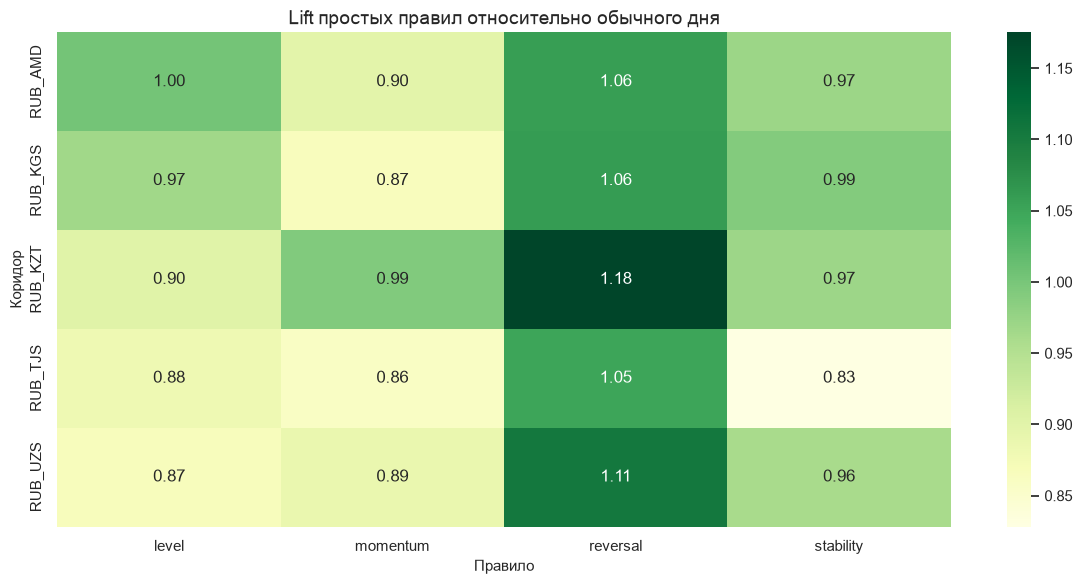

**Результат:** простые правила объяснимы, но работают нестабильно. Это и стало причиной добавить ML, который объединяет признаки и учитывает их взаимодействия.

In [10]:
simple_results = evaluate_simple_rules(rates)
display(simple_results.round(3))

simple_pivot = simple_results.pivot(index="corridor", columns="indicator", values="lift")
sns.heatmap(simple_pivot, annot=True, fmt=".2f", cmap="YlGn", center=1.0)
plt.title("Lift простых правил относительно обычного дня")
plt.xlabel("Правило")
plt.ylabel("Коридор")
plt.tight_layout()
plt.show()

display(Markdown(
    "**Результат:** простые правила объяснимы, но работают нестабильно. "
    "Это и стало причиной добавить ML, который объединяет признаки и учитывает их взаимодействия."
))

## 7. Что является целью ML

Для каждой исторической даты создаём ответ:

```text
target = 1 — дата оказалась около локального минимума;
target = 0 — не оказалась.
```

Дата считается около минимума, если её курс находится не дальше 25 б.п. от минимального курса в окне ±5 публикаций.

**Важный момент:** будущие пять публикаций здесь используются только для создания исторического правильного ответа. В признаках будущего нет. Последние пять дат вообще нельзя размечать — их будущее ещё неизвестно.

Для продуктовой проверки можно дополнительно использовать forward-only определение: не стал ли курс заметно выгоднее после пуша. На QA-сессии стоит подтвердить, какую формулировку кейсодатель считает основной.

In [11]:
example_target = simple_signal_frame(rates, "RUB_TJS")[
    ["available_date", "rub_per_unit", "target", "benefit_bps"]
].dropna().tail(12)
display(example_target)
display(Markdown(
    f"Доля положительного класса для RUB→TJS: **{example_target.target.mean():.1%}** в показанном фрагменте. "
    "По всей истории долю считаем ниже при построении датасета."
))

,available_date,rub_per_unit,target,benefit_bps
24670,2026-08-07,8.80312,False,11.647730
24671,2026-08-08,8.88517,False,-30.008123
24672,2026-08-11,8.92710,False,-16.828228
24673,2026-08-12,8.90205,False,66.648591
24674,2026-08-13,8.96991,False,33.633661
24675,2026-08-14,9.04757,False,-27.554360
24676,2026-08-15,9.12736,False,-98.084720
24677,2026-08-18,9.18143,False,-144.816023
24678,2026-08-19,9.19991,False,-144.639755
24679,2026-08-20,9.19611,False,-119.748261


Доля положительного класса для RUB→TJS: **8.3%** в показанном фрагменте. По всей истории долю считаем ниже при построении датасета.

## 8. Признаки для модели

Модель не видит слова «курс дешёвый». Она получает строку чисел. Мы строим 36 признаков:

- изменения за 1/3/5/10/20 публикаций;
- волатильность за 5 и 20 публикаций;
- положение курса в диапазоне за 20/60/120 публикаций;
- расстояние до локальных минимумов и максимума;
- длина серий роста и снижения, ускорение;
- сезонность месяца;
- движение USD/EUR/CNY;
- расстояние до праздников России и страны получателя.

Все скользящие показатели смотрят только назад. Контекстные валюты присоединяются по последней уже доступной дате.

In [12]:
FEATURE_NAMES = (
    "return_1_bps", "return_3_bps", "return_5_bps", "return_10_bps", "return_20_bps",
    "volatility_5_bps", "volatility_20_bps", "rank_20", "rank_60", "rank_120",
    "distance_min_20_bps", "distance_min_60_bps", "distance_max_20_bps",
    "down_streak", "up_streak", "acceleration_bps", "month_sin", "month_cos",
    "usd_return_1_bps", "usd_return_5_bps", "usd_return_20_bps", "usd_volatility_20_bps",
    "eur_return_1_bps", "eur_return_5_bps", "eur_return_20_bps", "eur_volatility_20_bps",
    "cny_return_1_bps", "cny_return_5_bps", "cny_return_20_bps", "cny_volatility_20_bps",
    "recipient_days_to_holiday_30", "recipient_days_since_holiday_30",
    "recipient_preholiday_7", "recipient_postholiday_3",
    "russia_days_to_holiday_30", "russia_preholiday_7",
)


def streak(values, direction):
    result = np.zeros(len(values), dtype=float)
    for index in range(1, len(values)):
        condition = values[index] < values[index - 1] if direction == "down" else values[index] > values[index - 1]
        result[index] = min(result[index - 1] + 1, 20) if condition else 0
    return result


def holiday_features(dates, country):
    years = range(dates.min().year - 1, dates.max().year + 2)
    calendar = sorted(holidays.country_holidays(country, years=list(years)).keys())
    ordinal = np.asarray([day.toordinal() for day in calendar])
    to_holiday, since_holiday = [], []
    for timestamp in dates:
        value = timestamp.date().toordinal()
        position = np.searchsorted(ordinal, value, side="right")
        previous = ordinal[position - 1] if position else value
        following = ordinal[position] if position < len(ordinal) else value
        to_holiday.append(min(following - value, 30))
        since_holiday.append(min(value - previous, 30))
    return np.asarray(to_holiday), np.asarray(since_holiday)


def context_feature_table(rates, currency):
    frame = rates[rates.currency == currency].sort_values("available_date")[["available_date", "rub_per_unit"]].copy()
    prefix = currency.lower()
    frame[f"{prefix}_return_1_bps"] = frame.rub_per_unit.pct_change(1) * 10_000
    frame[f"{prefix}_return_5_bps"] = frame.rub_per_unit.pct_change(5) * 10_000
    frame[f"{prefix}_return_20_bps"] = frame.rub_per_unit.pct_change(20) * 10_000
    one_day = frame.rub_per_unit.pct_change(1) * 10_000
    frame[f"{prefix}_volatility_20_bps"] = one_day.rolling(20).std(ddof=0)
    return frame.drop(columns="rub_per_unit")


def build_feature_table(rates, corridor, horizon=HORIZON):
    frame = rates[rates.corridor == corridor].sort_values("available_date")[[
        "available_date", "currency", "corridor", "rub_per_unit"
    ]].copy().reset_index(drop=True)
    value = frame.rub_per_unit
    one_day = value.pct_change(1) * 10_000

    for lag in (1, 3, 5, 10, 20):
        frame[f"return_{lag}_bps"] = value.pct_change(lag) * 10_000
    frame["volatility_5_bps"] = one_day.rolling(5).std(ddof=0)
    frame["volatility_20_bps"] = one_day.rolling(20).std(ddof=0)
    for window in (20, 60, 120):
        frame[f"rank_{window}"] = trailing_rank(value, window)
    frame["distance_min_20_bps"] = (value / value.rolling(20).min() - 1) * 10_000
    frame["distance_min_60_bps"] = (value / value.rolling(60).min() - 1) * 10_000
    frame["distance_max_20_bps"] = (value / value.rolling(20).max() - 1) * 10_000
    frame["down_streak"] = streak(value.to_numpy(), "down")
    frame["up_streak"] = streak(value.to_numpy(), "up")
    frame["acceleration_bps"] = one_day - one_day.shift(1)

    angle = 2 * np.pi * (frame.available_date.dt.month - 1) / 12
    frame["month_sin"] = np.sin(angle)
    frame["month_cos"] = np.cos(angle)

    for context_currency in CONTEXT_CURRENCIES:
        context = context_feature_table(rates, context_currency)
        frame = pd.merge_asof(
            frame.sort_values("available_date"), context.sort_values("available_date"),
            on="available_date", direction="backward"
        )

    recipient_country = CORRIDOR_COUNTRIES[corridor.replace("RUB_", "")]
    recipient_to, recipient_since = holiday_features(frame.available_date, recipient_country)
    russia_to, russia_since = holiday_features(frame.available_date, "RU")
    frame["recipient_days_to_holiday_30"] = recipient_to / 30
    frame["recipient_days_since_holiday_30"] = recipient_since / 30
    frame["recipient_preholiday_7"] = ((recipient_to > 0) & (recipient_to <= 7)).astype(float)
    frame["recipient_postholiday_3"] = (recipient_since <= 3).astype(float)
    frame["russia_days_to_holiday_30"] = russia_to / 30
    frame["russia_preholiday_7"] = ((russia_to > 0) & (russia_to <= 7)).astype(float)

    frame = add_historical_target(frame, horizon=horizon)
    return frame

In [13]:
feature_tables = {
    f"RUB_{currency}": build_feature_table(rates, f"RUB_{currency}")
    for currency in RECIPIENT_CURRENCIES
}
datasets = {
    corridor: table.dropna(subset=list(FEATURE_NAMES) + ["target"]).reset_index(drop=True)
    for corridor, table in feature_tables.items()
}

dataset_summary = pd.DataFrame([
    {
        "corridor": corridor,
        "rows_for_ml": len(table),
        "positive_class_share": table.target.mean(),
        "first_date": table.available_date.min(),
        "last_labeled_date": table.available_date.max(),
    }
    for corridor, table in datasets.items()
])
display(dataset_summary)

display(Markdown(
    f"**Признаки подготовлены:** у каждой даты теперь {len(FEATURE_NAMES)} признаков и один исторический ответ. "
    "Последние даты без известного будущего в обучение не попали."
))

,corridor,rows_for_ml,positive_class_share,first_date,last_labeled_date
0,RUB_TJS,3990,0.111779,2010-07-03,2026-08-22
1,RUB_UZS,3990,0.113784,2010-07-03,2026-08-22
2,RUB_KGS,3990,0.126566,2010-07-03,2026-08-22
3,RUB_AMD,3990,0.109273,2010-07-03,2026-08-22
4,RUB_KZT,3991,0.123779,2010-07-02,2026-08-22


**Признаки подготовлены:** у каждой даты теперь 36 признаков и один исторический ответ. Последние даты без известного будущего в обучение не попали.

## 9. Какие модели сравниваем

Теперь начинается ML-слой. Все модели получают абсолютно одинаковые признаки и одинаковые временные отрезки.

1. **Logistic Regression** — простой и хорошо объяснимый baseline.
2. **HistGradientBoosting** — последовательность небольших деревьев, умеющая находить нелинейные сочетания.
3. **Extra Trees** — ансамбль независимых случайных деревьев.

Модель обучается выдавать вероятность `P(target=1)`. Внутри обучение минимизирует log loss. Но пуш мы оцениваем не по log loss, а по hit rate, lift, выгоде, частоте, кучности и качеству вероятностей.

In [14]:
MODEL_NAMES = ("logistic", "hist_gradient_boosting", "extra_trees")


def build_model(name):
    if name == "logistic":
        return make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED),
        )
    if name == "hist_gradient_boosting":
        return HistGradientBoostingClassifier(
            learning_rate=0.08,
            max_iter=60,
            max_leaf_nodes=7,
            min_samples_leaf=20,
            l2_regularization=1.0,
            class_weight="balanced",
            random_state=SEED,
        )
    if name == "extra_trees":
        return ExtraTreesClassifier(
            n_estimators=60,
            max_depth=8,
            min_samples_leaf=10,
            max_features=0.8,
            class_weight="balanced",
            n_jobs=-1,
            random_state=SEED,
        )
    raise ValueError(f"Неизвестная модель: {name}")


[build_model(name) for name in MODEL_NAMES]

[Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('logisticregression',
                  LogisticRegression(class_weight='balanced', max_iter=2000,
                                     random_state=42))]),
 HistGradientBoostingClassifier(class_weight='balanced', l2_regularization=1.0,
                                learning_rate=0.08, max_iter=60,
                                max_leaf_nodes=7, random_state=42),
 ExtraTreesClassifier(class_weight='balanced', max_depth=8, max_features=0.8,
                      min_samples_leaf=10, n_estimators=60, n_jobs=-1,
                      random_state=42)]

## 10. Как считаем ошибку и выбираем порог

Рассматриваем три уровня ошибки:

1. **Log loss** — по нему модель учится выдавать вероятности.
2. **Brier score** — проверяет, насколько вероятности похожи на реальность: `mean((p-y)²)`.
3. **Бизнес-ошибка порога** — ложный пуш дороже пропущенного момента:

```text
cost = (4 × FP + 1 × FN) / число дат
```

Где FP — мы отправили плохой сигнал, FN — пропустили хороший момент. Порог перебирается только на прошлом валидационном участке. Также мы не разрешаем модели генерировать больше двух сигналов в неделю.

In [15]:
def select_with_cooldown(probabilities, threshold, cooldown=COOLDOWN_UPDATES):
    selected = []
    last = -cooldown - 1
    for index, probability in enumerate(probabilities):
        if probability >= threshold and index - last > cooldown:
            selected.append(index)
            last = index
    return selected


def choose_threshold(probabilities, labels, dates, false_positive_cost=FALSE_POSITIVE_COST,
                     cooldown=COOLDOWN_UPDATES, min_weekly_rate=MIN_WEEKLY_RATE):
    span_weeks = max((pd.Timestamp(dates[-1]) - pd.Timestamp(dates[0])).days / 7, 1)
    valid_candidates = []
    fallbacks = []
    for threshold in np.arange(0.10, 0.951, 0.025):
        selected = select_with_cooldown(probabilities, threshold, cooldown)
        rate = len(selected) / span_weeks
        if not selected or rate > 2.0:
            continue
        selected_set = set(selected)
        false_positives = sum(labels[index] == 0 for index in selected)
        false_negatives = sum(labels[index] == 1 for index in range(len(labels)) if index not in selected_set)
        cost = (false_positive_cost * false_positives + false_negatives) / len(labels)
        fallbacks.append((abs(rate - min_weekly_rate), cost, float(threshold)))
        if rate >= min_weekly_rate:
            valid_candidates.append((cost, float(threshold)))
    if valid_candidates:
        return min(valid_candidates)[1]
    return min(fallbacks)[2] if fallbacks else 0.95


def timing_indices(probabilities, threshold, strong_margin=STRONG_MARGIN,
                   cooldown=COOLDOWN_UPDATES):
    strong_threshold = min(threshold + strong_margin, 0.95)
    candidates = []
    for index, probability in enumerate(probabilities):
        if probability >= strong_threshold:
            candidates.append((index, "fast"))
        elif index > 0 and probability >= threshold and probabilities[index - 1] >= threshold:
            candidates.append((index, "confirmed"))

    selected = []
    for index, speed in candidates:
        if not selected or index - selected[-1][0] > cooldown:
            selected.append((index, speed))
    return selected

## 11. Walk-forward: честная проверка во времени

Это ключевая часть проверки.

```text
обучение → валидация порога → невидимый тест
```

После теста двигаемся вперёд и повторяем. Перед границами выкидываем `h` наблюдений, потому что их историческая метка зависит от следующего блока.

В каждом фолде:

- минимум 750 старых наблюдений идут в историю;
- 200 используются для выбора порога;
- 125 следующих публикаций — честный тест;
- параметры модели и порог не смотрят на тестовые ответы.

In [16]:
def clustered_share(indices, dates):
    if len(indices) < 2:
        return 0.0
    intervals = [
        (pd.Timestamp(dates[right]) - pd.Timestamp(dates[left])).days
        for left, right in zip(indices, indices[1:])
    ]
    return float(np.mean(np.asarray(intervals) <= 3))


def walk_forward_compare(dataset, corridor, horizon=HORIZON, min_train=750,
                         validation_size=200, test_size=125,
                         target_column="target", model_names=MODEL_NAMES):
    x = dataset[list(FEATURE_NAMES)].to_numpy(dtype=float)
    y = dataset[target_column].to_numpy(dtype=int)
    message_y = dataset.good_now_hit.to_numpy(dtype=int)
    dates = dataset.available_date.to_numpy()
    event_eligible = policy_event_eligibility(corridor, dates, horizon)
    benefits = dataset.benefit_bps.to_numpy(dtype=float)
    rows = []
    test_start = min_train
    fold = 0

    while test_start + test_size <= len(dataset):
        validation_start = test_start - validation_size
        fit_end = validation_start - horizon
        validation_end = test_start - horizon
        test_end = test_start + test_size

        for model_name in model_names:
            calibration_model = build_model(model_name)
            calibration_model.fit(x[:fit_end], y[:fit_end])
            validation_probabilities = calibration_model.predict_proba(
                x[validation_start:validation_end]
            )[:, 1]
            threshold = choose_threshold(
                validation_probabilities,
                y[validation_start:validation_end],
                dates[validation_start:validation_end],
            )

            model = build_model(model_name)
            train_end = test_start - horizon
            model.fit(x[:train_end], y[:train_end])
            probabilities = model.predict_proba(x[test_start:test_end])[:, 1]
            decisions = timing_indices(probabilities, threshold)
            raw_selected = [index for index, _ in decisions]
            blocked = [
                index for index in raw_selected
                if not event_eligible[test_start + index]
            ]
            selected_decisions = [
                (index, speed) for index, speed in decisions
                if event_eligible[test_start + index]
            ]
            selected = [index for index, _ in selected_decisions]
            speeds = [speed for _, speed in selected_decisions]

            test_y = y[test_start:test_end]
            test_message_y = message_y[test_start:test_end]
            test_dates = dates[test_start:test_end]
            baseline = float(test_y.mean())
            hit_rate = float(test_y[selected].mean()) if selected else 0.0
            message_baseline = float(test_message_y.mean())
            message_hit_rate = float(test_message_y[selected].mean()) if selected else 0.0
            raw_message_hit_rate = (
                float(test_message_y[raw_selected].mean()) if raw_selected else 0.0
            )
            span_weeks = max((pd.Timestamp(test_dates[-1]) - pd.Timestamp(test_dates[0])).days / 7, 1)

            rows.append({
                "corridor": corridor,
                "model": model_name,
                "training_target": target_column,
                "fold": fold,
                "train_end": pd.Timestamp(dates[train_end - 1]),
                "test_start": pd.Timestamp(test_dates[0]),
                "test_end": pd.Timestamp(test_dates[-1]),
                "threshold": threshold,
                "raw_signals": len(raw_selected),
                "blocked_policy_event_signals": len(raw_selected) - len(selected),
                "blocked_policy_event_hits": int(test_message_y[blocked].sum()),
                "blocked_policy_event_false_positives": int(
                    len(blocked) - test_message_y[blocked].sum()
                ),
                "signals": len(selected),
                "fast_signals": speeds.count("fast"),
                "confirmed_signals": speeds.count("confirmed"),
                "hit_rate": hit_rate,
                "baseline_hit_rate": baseline,
                "lift": hit_rate / baseline if baseline and selected else 0.0,
                "message_hit_rate": message_hit_rate,
                "raw_message_hit_rate": raw_message_hit_rate,
                "message_baseline_hit_rate": message_baseline,
                "message_lift": message_hit_rate / message_baseline if message_baseline and selected else 0.0,
                "mean_benefit_bps": float(benefits[test_start:test_end][selected].mean()) if selected else 0.0,
                "signals_per_week": len(selected) / span_weeks,
                "clustered_share": clustered_share(selected, test_dates),
                "brier_score": brier_score_loss(test_y, probabilities),
            })

        fold += 1
        test_start += test_size
    return pd.DataFrame(rows)

In [17]:
fold_parts = []
for corridor, dataset in datasets.items():
    print(f"Считаем {corridor}...")
    fold_parts.append(walk_forward_compare(dataset, corridor))

folds = pd.concat(fold_parts, ignore_index=True)
print(f"Готово: {len(folds)} результатов = коридоры × модели × временные фолды")
display(folds.head())

Считаем RUB_TJS...


Считаем RUB_UZS...


Считаем RUB_KGS...


Считаем RUB_AMD...


Считаем RUB_KZT...


Готово: 375 результатов = коридоры × модели × временные фолды


,corridor,model,training_target,fold,train_end,test_start,test_end,threshold,raw_signals,blocked_policy_event_signals,blocked_policy_event_hits,blocked_policy_event_false_positives,signals,fast_signals,confirmed_signals,hit_rate,baseline_hit_rate,lift,message_hit_rate,raw_message_hit_rate,message_baseline_hit_rate,message_lift,mean_benefit_bps,signals_per_week,clustered_share,brier_score
0,RUB_TJS,logistic,target,0,2013-07-03,2013-07-11,2014-01-10,0.100,56,0,0,0,56,46,10,0.285714,0.200,1.428571,0.482143,0.482143,0.432,1.116071,21.215664,2.142077,0.545455,0.278843
1,RUB_TJS,hist_gradient_boosting,target,0,2013-07-03,2013-07-11,2014-01-10,0.100,28,0,0,0,28,28,0,0.428571,0.200,2.142857,0.464286,0.464286,0.432,1.074735,59.022337,1.071038,0.333333,0.147844
2,RUB_TJS,extra_trees,target,0,2013-07-03,2013-07-11,2014-01-10,0.125,39,0,0,0,39,29,10,0.307692,0.200,1.538462,0.435897,0.435897,0.432,1.009022,31.462073,1.491803,0.447368,0.128621
3,RUB_TJS,logistic,target,1,2013-12-26,2014-01-11,2014-07-12,0.100,32,0,0,0,32,28,4,0.156250,0.072,2.170139,0.312500,0.312500,0.336,0.930060,44.705108,1.230769,0.387097,0.170771
4,RUB_TJS,hist_gradient_boosting,target,1,2013-12-26,2014-01-11,2014-07-12,0.100,25,0,0,0,25,25,0,0.240000,0.072,3.333333,0.240000,0.240000,0.336,0.714286,52.430921,0.961538,0.375000,0.108529


## 12. Агрегируем результаты

Отдельный фолд может быть лёгким или тяжёлым. Поэтому финальный результат собираем по всем временным тестам:

- hit rate взвешиваем количеством отправленных сигналов;
- baseline — обычная доля хороших дней в тех же тестовых периодах;
- lift = hit rate / baseline;
- Brier оценивает вероятности на всех тестовых датах;
- отдельно смотрим, в скольких фолдах lift был не ниже 1,3.

Мы честно выводим **два lift**. `lift` отвечает, попала ли модель в свою учебную цель — локальный минимум. `message_lift` отвечает, было ли правдивым клиентское «сейчас относительно выгодно», то есть не появился ли заметно лучший курс сразу после пуша. Не смешиваем ML-метрику и продуктовую проверку.

In [18]:
def aggregate_group(group):
    raw_signals = int(group.raw_signals.sum())
    signals = int(group.signals.sum())
    hit_rate = float((group.hit_rate * group.signals).sum() / signals) if signals else 0.0
    baseline = float(group.baseline_hit_rate.mean())
    message_hit_rate = float((group.message_hit_rate * group.signals).sum() / signals) if signals else 0.0
    raw_message_hit_rate = (
        float((group.raw_message_hit_rate * group.raw_signals).sum() / raw_signals)
        if raw_signals else 0.0
    )
    message_baseline = float(group.message_baseline_hit_rate.mean())
    benefit = float((group.mean_benefit_bps * group.signals).sum() / signals) if signals else 0.0
    return {
        "folds": len(group),
        "raw_signals": raw_signals,
        "blocked_policy_event_signals": int(group.blocked_policy_event_signals.sum()),
        "blocked_policy_event_hits": int(group.blocked_policy_event_hits.sum()),
        "blocked_policy_event_false_positives": int(
            group.blocked_policy_event_false_positives.sum()
        ),
        "signals": signals,
        "hit_rate": hit_rate,
        "baseline_hit_rate": baseline,
        "lift": hit_rate / baseline if baseline else 0.0,
        "message_hit_rate": message_hit_rate,
        "raw_message_hit_rate": raw_message_hit_rate,
        "raw_message_lift": raw_message_hit_rate / message_baseline if message_baseline else 0.0,
        "message_baseline_hit_rate": message_baseline,
        "message_lift": message_hit_rate / message_baseline if message_baseline else 0.0,
        "mean_benefit_bps": benefit,
        "signals_per_week": float(group.signals_per_week.mean()),
        "clustered_share": float(group.clustered_share.mean()),
        "brier_score": float(group.brier_score.mean()),
        "folds_lift_ge_1_3": int((group.lift >= 1.3).sum()),
    }


summary_rows = []
for (corridor, model_name), group in folds.groupby(["corridor", "model"], sort=False):
    summary_rows.append({"corridor": corridor, "model": model_name, **aggregate_group(group)})
summary = pd.DataFrame(summary_rows)

lift_table = summary.pivot(index="corridor", columns="model", values="lift").reindex(
    columns=list(MODEL_NAMES)
)
message_lift_table = summary.pivot(index="corridor", columns="model", values="message_lift").reindex(
    columns=list(MODEL_NAMES)
)
display(Markdown("### Lift по ML-цели: попали ли в локальный минимум"))
display(lift_table.round(3))
display(Markdown("### Lift по правдивости сообщения: не стало ли после пуша заметно выгоднее"))
display(message_lift_table.round(3))
display(summary.round(3))

### Lift по ML-цели: попали ли в локальный минимум

model,logistic,hist_gradient_boosting,extra_trees
corridor,,,
RUB_AMD,1.945,2.610,2.111
RUB_KGS,2.082,2.604,1.979
RUB_KZT,1.949,2.450,2.058
RUB_TJS,1.947,2.640,2.063
RUB_UZS,1.957,2.512,1.987


### Lift по правдивости сообщения: не стало ли после пуша заметно выгоднее

model,logistic,hist_gradient_boosting,extra_trees
corridor,,,
RUB_AMD,0.969,0.952,0.963
RUB_KGS,1.019,1.079,1.027
RUB_KZT,1.007,0.952,0.974
RUB_TJS,0.999,0.915,0.962
RUB_UZS,0.918,0.947,0.934


,corridor,model,folds,raw_signals,blocked_policy_event_signals,blocked_policy_event_hits,blocked_policy_event_false_positives,signals,hit_rate,baseline_hit_rate,lift,message_hit_rate,raw_message_hit_rate,raw_message_lift,message_baseline_hit_rate,message_lift,mean_benefit_bps,signals_per_week,clustered_share,brier_score,folds_lift_ge_1_3
0,RUB_TJS,logistic,25,807,0,0,0,807,0.217,0.111,1.947,0.369,0.369,0.999,0.370,0.999,44.240,1.232,0.391,0.171,22
1,RUB_TJS,hist_gradient_boosting,25,704,0,0,0,704,0.294,0.111,2.640,0.338,0.338,0.915,0.370,0.915,60.501,1.074,0.381,0.133,24
2,RUB_TJS,extra_trees,25,827,0,0,0,827,0.230,0.111,2.063,0.356,0.356,0.962,0.370,0.962,45.726,1.262,0.419,0.140,24
3,RUB_UZS,logistic,25,798,2,0,2,796,0.217,0.111,1.957,0.320,0.320,0.915,0.349,0.918,43.763,1.215,0.402,0.182,24
4,RUB_UZS,hist_gradient_boosting,25,719,2,0,2,717,0.279,0.111,2.512,0.331,0.330,0.944,0.349,0.947,52.988,1.094,0.362,0.139,25
5,RUB_UZS,extra_trees,25,827,2,0,2,825,0.221,0.111,1.987,0.326,0.325,0.932,0.349,0.934,44.493,1.259,0.419,0.143,24
6,RUB_KGS,logistic,25,773,0,0,0,773,0.266,0.128,2.082,0.374,0.374,1.019,0.367,1.019,50.221,1.180,0.398,0.163,22
7,RUB_KGS,hist_gradient_boosting,25,702,0,0,0,702,0.333,0.128,2.604,0.396,0.396,1.079,0.367,1.079,65.494,1.071,0.353,0.134,24
8,RUB_KGS,extra_trees,25,833,0,0,0,833,0.253,0.128,1.979,0.377,0.377,1.027,0.367,1.027,52.032,1.272,0.403,0.143,23
9,RUB_AMD,logistic,25,763,0,0,0,763,0.211,0.108,1.945,0.360,0.360,0.969,0.372,0.969,44.441,1.165,0.354,0.158,22


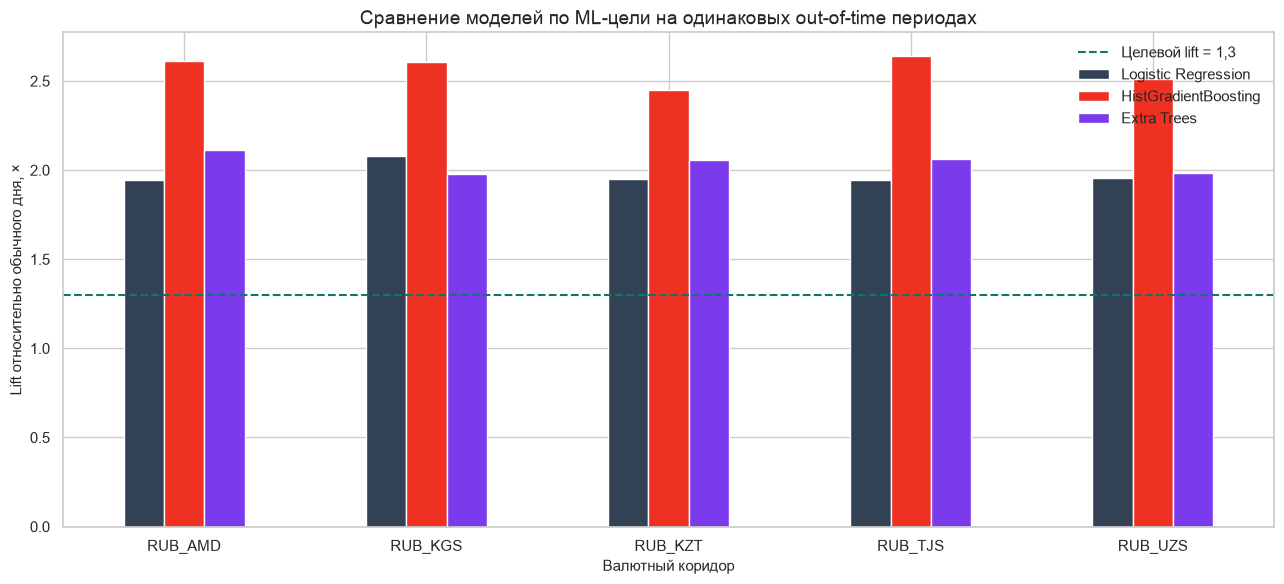

**Результат по ML-цели:** HistGradientBoosting даёт lift от **2.45** до **2.64** при частоте 1.03–1.09 сигнала в неделю. Правдивость клиентского сообщения отдельно отражена в `message_lift`: 0.91–1.08.

In [19]:
plot_table = lift_table.rename(columns={
    "logistic": "Logistic Regression",
    "hist_gradient_boosting": "HistGradientBoosting",
    "extra_trees": "Extra Trees",
})
ax = plot_table.plot(kind="bar", figsize=(13, 6), color=["#334155", "#EF3124", "#7C3AED"])
ax.axhline(1.3, color="#0F766E", linestyle="--", label="Целевой lift = 1,3")
ax.set_title("Сравнение моделей по ML-цели на одинаковых out-of-time периодах")
ax.set_xlabel("Валютный коридор")
ax.set_ylabel("Lift относительно обычного дня, ×")
ax.legend(frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

hgb = summary[summary.model == "hist_gradient_boosting"]
display(Markdown(
    f"**Результат по ML-цели:** HistGradientBoosting даёт lift "
    f"от **{hgb.lift.min():.2f}** до **{hgb.lift.max():.2f}** при частоте "
    f"{hgb.signals_per_week.min():.2f}–{hgb.signals_per_week.max():.2f} сигнала в неделю. "
    f"Правдивость клиентского сообщения отдельно отражена в `message_lift`: "
    f"{hgb.message_lift.min():.2f}–{hgb.message_lift.max():.2f}."
))

### 12.1. Методический аудит: а что, если учить сразу правдивость пуша?

Важно учитывать ограничение результата. Высокий lift по локальному минимуму ещё не гарантирует высокий `message_lift`. Поэтому проводим дополнительный эксперимент: обучаем Logistic Regression и HistGradientBoosting напрямую на `good_now_hit`.

Это отвечает уже не на вопрос «похож ли день на локальный минимум?», а на вопрос:

> «Если написать сегодня, не появится ли в следующие пять публикаций заметно более выгодный курс?»

Если и этот вариант не достигает lift 1,3, честный вывод — дневного ряда и текущих признаков недостаточно для обещания `good_now`; тогда нужно менять текст сигнала, данные, горизонт или постановку цели.

In [20]:
forward_parts = []
for corridor, dataset in datasets.items():
    print(f"Проверяем forward-цель для {corridor}...")
    forward_parts.append(walk_forward_compare(
        dataset,
        corridor,
        target_column="good_now_hit",
        model_names=("logistic", "hist_gradient_boosting"),
    ))
forward_folds = pd.concat(forward_parts, ignore_index=True)

forward_rows = []
for (corridor, model_name), group in forward_folds.groupby(["corridor", "model"], sort=False):
    forward_rows.append({"corridor": corridor, "model": model_name, **aggregate_group(group)})
forward_summary = pd.DataFrame(forward_rows)
forward_table = forward_summary.pivot(index="corridor", columns="model", values="lift")
display(forward_table.round(3))

forward_hgb = forward_summary[forward_summary.model == "hist_gradient_boosting"]
target_passed = bool((forward_hgb.lift >= 1.3).all())
verdict = (
    "проходит целевой lift 1,3 на всех коридорах"
    if target_passed
    else "не проходит целевой lift 1,3 на всех коридорах — это честное ограничение текущего решения"
)
display(Markdown(
    f"**Результат прямого обучения на правдивость пуша:** lift "
    f"{forward_hgb.lift.min():.2f}–{forward_hgb.lift.max():.2f}; модель **{verdict}**."
))

event_guard_audit = forward_hgb[
    forward_hgb.corridor.isin(POLICY_EVENTS.corridor.unique())
][[
    "corridor", "raw_signals", "blocked_policy_event_signals", "signals",
    "blocked_policy_event_hits", "blocked_policy_event_false_positives",
    "raw_message_lift", "message_lift",
]]
event_guard_audit = event_guard_audit.assign(
    asymmetric_error_reduction=lambda frame:
    FALSE_POSITIVE_COST * frame.blocked_policy_event_false_positives
    - frame.blocked_policy_event_hits
)
display(Markdown("### Что изменил фильтр официальных событий"))
display(event_guard_audit.round(4))
display(Markdown(
    "**Вывод:** фильтр меняет всего несколько пушей. По отдельным коридорам "
    "изменение lift может быть положительным или отрицательным, поэтому мы не называем его "
    "улучшением ML. Смотрим на `asymmetric_error_reduction`: положительное значение означает, "
    "что при цене ложного пуша ×4 страховка полезна. Для будущих событий нужен оперативно "
    "обновляемый источник решений центральных банков, иначе календарь быстро устареет."
))

Проверяем forward-цель для RUB_TJS...


Проверяем forward-цель для RUB_UZS...


Проверяем forward-цель для RUB_KGS...


Проверяем forward-цель для RUB_AMD...


Проверяем forward-цель для RUB_KZT...


model,hist_gradient_boosting,logistic
corridor,,
RUB_AMD,1.099,1.120
RUB_KGS,1.063,1.039
RUB_KZT,1.037,1.046
RUB_TJS,1.127,1.066
RUB_UZS,1.152,1.046


**Результат прямого обучения на правдивость пуша:** lift 1.04–1.15; модель **не проходит целевой lift 1,3 на всех коридорах — это честное ограничение текущего решения**.

### Что изменил фильтр официальных событий

,corridor,raw_signals,blocked_policy_event_signals,signals,blocked_policy_event_hits,blocked_policy_event_false_positives,raw_message_lift,message_lift,asymmetric_error_reduction
3,RUB_UZS,821,3,818,1,2,1.1513,1.1520,7.0
9,RUB_KZT,834,5,829,2,3,1.0379,1.0375,10.0


**Вывод:** фильтр меняет всего несколько пушей. По отдельным коридорам изменение lift может быть положительным или отрицательным, поэтому мы не называем его улучшением ML. Смотрим на `asymmetric_error_reduction`: положительное значение означает, что при цене ложного пуша ×4 страховка полезна. Для будущих событий нужен оперативно обновляемый источник решений центральных банков, иначе календарь быстро устареет.

## 13. Статистическое сравнение моделей

Просто увидеть более высокий столбик недостаточно. Мы парно сравниваем модели на одних и тех же временных фолдах.

Bootstrap много раз случайно пересобирает набор фолдов и считает разницу lift. Если весь 95% интервал разницы выше нуля, говорим, что кандидат статистически лучше логистики.

In [21]:
def aggregate_lift(group):
    signals = group.signals.sum()
    if not signals:
        return 0.0
    hit_rate = (group.hit_rate * group.signals).sum() / signals
    baseline = group.baseline_hit_rate.mean()
    return float(hit_rate / baseline) if baseline else 0.0


def paired_bootstrap_delta(candidate, baseline, samples=2000):
    candidate = candidate.sort_values("fold").reset_index(drop=True)
    baseline = baseline.sort_values("fold").reset_index(drop=True)
    assert candidate.fold.tolist() == baseline.fold.tolist()
    rng = np.random.default_rng(SEED)
    deltas = []
    for _ in range(samples):
        indices = rng.integers(0, len(candidate), len(candidate))
        deltas.append(
            aggregate_lift(candidate.iloc[indices]) - aggregate_lift(baseline.iloc[indices])
        )
    actual = aggregate_lift(candidate) - aggregate_lift(baseline)
    low, high = np.quantile(deltas, [0.025, 0.975])
    return actual, low, high


comparison_rows = []
for corridor in sorted(folds.corridor.unique()):
    logistic = folds[(folds.corridor == corridor) & (folds.model == "logistic")]
    for candidate_name in ("hist_gradient_boosting", "extra_trees"):
        candidate = folds[(folds.corridor == corridor) & (folds.model == candidate_name)]
        delta, low, high = paired_bootstrap_delta(candidate, logistic)
        comparison_rows.append({
            "corridor": corridor,
            "candidate": candidate_name,
            "lift_delta": delta,
            "ci_low": low,
            "ci_high": high,
            "statistically_better": low > 0,
        })
comparisons = pd.DataFrame(comparison_rows)
display(comparisons.round(3))

,corridor,candidate,lift_delta,ci_low,ci_high,statistically_better
0,RUB_AMD,hist_gradient_boosting,0.665,0.417,0.891,True
1,RUB_AMD,extra_trees,0.166,-0.079,0.382,False
2,RUB_KGS,hist_gradient_boosting,0.522,0.277,0.734,True
3,RUB_KGS,extra_trees,-0.103,-0.331,0.105,False
4,RUB_KZT,hist_gradient_boosting,0.501,0.275,0.720,True
5,RUB_KZT,extra_trees,0.109,-0.129,0.339,False
6,RUB_TJS,hist_gradient_boosting,0.693,0.435,0.970,True
7,RUB_TJS,extra_trees,0.116,-0.076,0.305,False
8,RUB_UZS,hist_gradient_boosting,0.555,0.334,0.778,True
9,RUB_UZS,extra_trees,0.029,-0.193,0.235,False


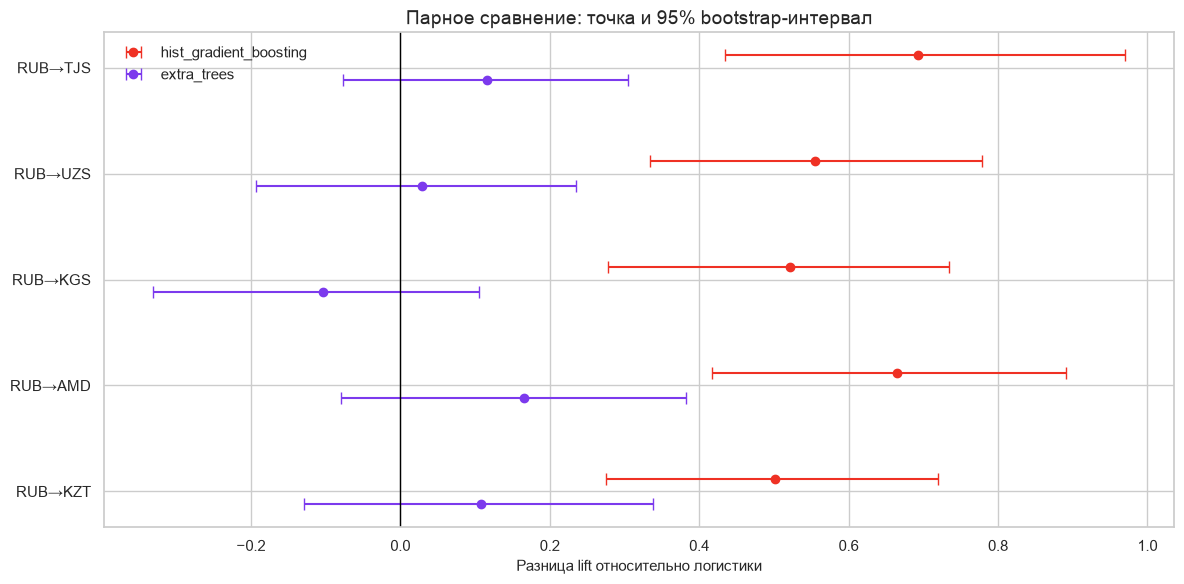

**Вывод:** у бустинга положительная нижняя граница интервала на **5 из 5** коридоров. Extra Trees оставляем исследовательским вариантом, если его интервалы пересекают ноль.

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))
positions = np.arange(len(RECIPIENT_CURRENCIES))
for offset, candidate_name, color in [
    (-0.12, "hist_gradient_boosting", "#EF3124"),
    (0.12, "extra_trees", "#7C3AED"),
]:
    part = comparisons[comparisons.candidate == candidate_name].set_index("corridor").loc[
        [f"RUB_{currency}" for currency in RECIPIENT_CURRENCIES]
    ]
    centers = part.lift_delta.to_numpy()
    errors = np.vstack([centers - part.ci_low.to_numpy(), part.ci_high.to_numpy() - centers])
    ax.errorbar(centers, positions + offset, xerr=errors, fmt="o", capsize=4,
                color=color, label=candidate_name)
ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(positions, [f"RUB→{currency}" for currency in RECIPIENT_CURRENCIES])
ax.invert_yaxis()
ax.set_xlabel("Разница lift относительно логистики")
ax.set_title("Парное сравнение: точка и 95% bootstrap-интервал")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

hgb_comparison = comparisons[comparisons.candidate == "hist_gradient_boosting"]
display(Markdown(
    f"**Вывод:** у бустинга положительная нижняя граница интервала на "
    f"**{hgb_comparison.statistically_better.sum()} из {len(hgb_comparison)}** коридоров. "
    "Extra Trees оставляем исследовательским вариантом, если его интервалы пересекают ноль."
))

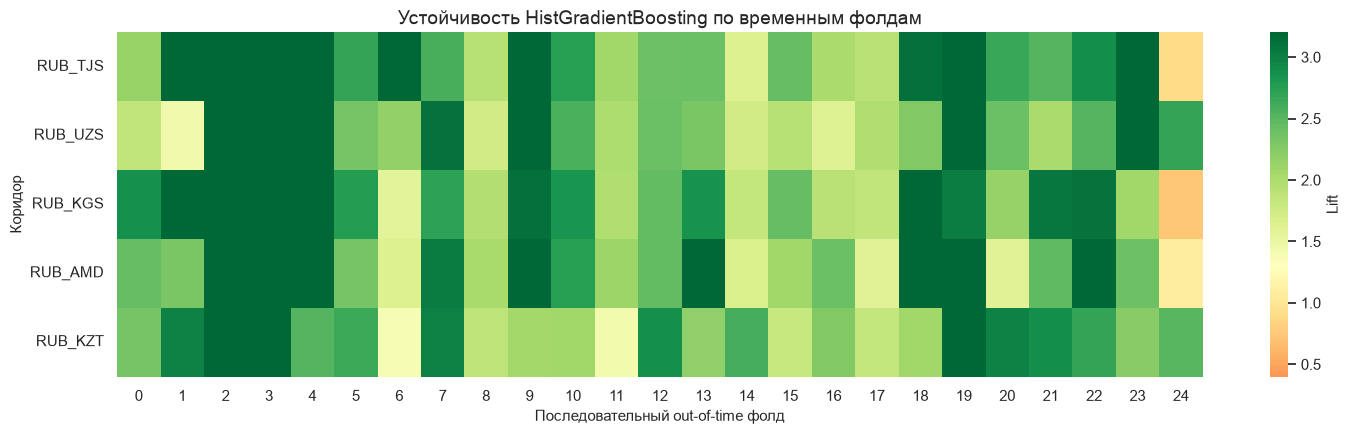

In [23]:
hgb_folds = folds[folds.model == "hist_gradient_boosting"].pivot(
    index="corridor", columns="fold", values="lift"
).reindex([f"RUB_{currency}" for currency in RECIPIENT_CURRENCIES])

plt.figure(figsize=(15, 4.5))
sns.heatmap(hgb_folds, cmap="RdYlGn", center=1.3, vmin=0.4, vmax=3.2, cbar_kws={"label": "Lift"})
plt.title("Устойчивость HistGradientBoosting по временным фолдам")
plt.xlabel("Последовательный out-of-time фолд")
plt.ylabel("Коридор")
plt.tight_layout()
plt.show()

## 14. Из вероятности делаем финальный сигнал

Модель сама пуш не отправляет. Финальный слой:

1. физически отрезает все данные после `as_of`;
2. на прошлом выбирает порог;
3. обучает победивший HistGradientBoosting;
4. смотрит три последние вероятности;
5. сильный сигнал помечает `fast`, пограничный ждёт второго превышения и становится `confirmed`;
6. добавляет наблюдаемый факт и локальное объяснение модели.

Локальное объяснение приблизительное: по очереди заменяем каждый признак медианой и смотрим, насколько упала вероятность. Это показывает вклад признака в расчёт, но не доказывает экономическую причинность.

In [24]:
FEATURE_LABELS = {
    "return_1_bps": "изменение за одну публикацию",
    "return_3_bps": "изменение за три публикации",
    "return_5_bps": "изменение за пять публикаций",
    "return_10_bps": "среднесрочная динамика",
    "return_20_bps": "динамика за 20 публикаций",
    "volatility_5_bps": "краткосрочная волатильность",
    "volatility_20_bps": "волатильность за 20 публикаций",
    "rank_20": "положение в диапазоне 20 публикаций",
    "rank_60": "положение в диапазоне 60 публикаций",
    "rank_120": "положение в диапазоне 120 публикаций",
    "distance_min_20_bps": "расстояние до недавнего минимума",
    "distance_min_60_bps": "расстояние до среднесрочного минимума",
    "distance_max_20_bps": "расстояние до недавнего максимума",
    "down_streak": "длина серии снижения",
    "up_streak": "длина серии роста",
    "acceleration_bps": "ускорение движения",
    "month_sin": "календарная сезонность",
    "month_cos": "календарная сезонность",
    "usd_return_1_bps": "однодневная динамика доллара",
    "usd_return_5_bps": "динамика доллара",
    "usd_return_20_bps": "среднесрочная динамика доллара",
    "usd_volatility_20_bps": "волатильность доллара",
    "eur_return_1_bps": "однодневная динамика евро",
    "eur_return_5_bps": "динамика евро",
    "eur_return_20_bps": "среднесрочная динамика евро",
    "eur_volatility_20_bps": "волатильность евро",
    "cny_return_1_bps": "однодневная динамика юаня",
    "cny_return_5_bps": "динамика юаня",
    "cny_return_20_bps": "среднесрочная динамика юаня",
    "cny_volatility_20_bps": "волатильность юаня",
    "recipient_days_to_holiday_30": "расстояние до праздника в стране получателя",
    "recipient_days_since_holiday_30": "расстояние от праздника в стране получателя",
    "recipient_preholiday_7": "близость праздника в стране получателя",
    "recipient_postholiday_3": "период после праздника в стране получателя",
    "russia_days_to_holiday_30": "расстояние до праздника в России",
    "russia_preholiday_7": "близость праздника в России",
}


def local_reasons(model, current_x, training_x, top_n=3):
    sample = np.asarray(current_x, dtype=float).reshape(1, -1)
    original_probability = model.predict_proba(sample)[0, 1]
    medians = np.median(training_x, axis=0)
    contributions = []
    for index, name in enumerate(FEATURE_NAMES):
        altered = sample.copy()
        altered[0, index] = medians[index]
        changed_probability = model.predict_proba(altered)[0, 1]
        contributions.append((original_probability - changed_probability, name))
    positive = sorted([item for item in contributions if item[0] > 0], reverse=True)
    selected = positive[:top_n] or sorted(contributions, key=lambda item: abs(item[0]), reverse=True)[:top_n]
    return [FEATURE_LABELS[name] for _, name in selected]


def signal_speed(probabilities, threshold, strong_margin=STRONG_MARGIN):
    strong_threshold = min(threshold + strong_margin, 0.95)
    if probabilities[-1] >= strong_threshold:
        return "fast"
    if probabilities[-1] >= threshold and probabilities[-2] >= threshold:
        return "confirmed"
    return None


def observable_explanation(row):
    percentile = round((1 - row.rank_60) * 100)
    if percentile >= 60:
        return f"Курс ниже, чем в {percentile}% последних 60 публикаций"
    change = row.return_5_bps / 100
    direction = "снизился" if change < 0 else "вырос"
    return f"За пять публикаций курс {direction} на {abs(change):.2f}%"


def final_signals_as_of(rates, as_of, model_name="hist_gradient_boosting"):
    as_of = pd.Timestamp(as_of)
    truncated = rates[rates.available_date <= as_of].copy()
    output = []

    for currency in RECIPIENT_CURRENCIES:
        corridor = f"RUB_{currency}"
        table = build_feature_table(truncated, corridor)
        training = table.dropna(subset=list(FEATURE_NAMES) + ["target"]).reset_index(drop=True)
        latest = table.dropna(subset=list(FEATURE_NAMES)).tail(3)
        if len(training) < 350 or len(latest) < 3:
            continue
        event_eligible = policy_event_eligibility(
            corridor, table.available_date.to_numpy(), HORIZON
        )
        if not event_eligible[-1]:
            continue

        x = training[list(FEATURE_NAMES)].to_numpy(dtype=float)
        y = training.target.to_numpy(dtype=int)
        validation_start = len(training) - 200
        fit_end = validation_start - HORIZON

        calibration_model = build_model(model_name)
        calibration_model.fit(x[:fit_end], y[:fit_end])
        validation_probabilities = calibration_model.predict_proba(x[validation_start:])[:, 1]
        threshold = choose_threshold(
            validation_probabilities,
            y[validation_start:],
            training.available_date.iloc[validation_start:].to_numpy(),
        )

        model = build_model(model_name)
        model.fit(x, y)
        latest_x = latest[list(FEATURE_NAMES)].to_numpy(dtype=float)
        probabilities = model.predict_proba(latest_x)[:, 1]
        speed = signal_speed(probabilities, threshold)
        if speed is None:
            continue

        current = latest.iloc[-1]
        output.append({
            "date": current.available_date.date(),
            "corridor": corridor,
            "indicator": f"{model_name}_local_minimum",
            "client_meaning": "много валюты получателя за рубль",
            "strength": float(probabilities[-1]),
            "threshold": float(threshold),
            "speed": speed,
            "recommended_scenario": "good_now",
            "explanation": observable_explanation(current),
            "model_reasons": ", ".join(local_reasons(model, latest_x[-1], x)),
        })
    return pd.DataFrame(output)

In [25]:
requested_demo_date = pd.Timestamp("2026-08-21")
demo_date = requested_demo_date if requested_demo_date <= rates.available_date.max() else rates.available_date.max()
final_signals = final_signals_as_of(rates, demo_date)

display(Markdown(f"### Сигналы так, как они выглядели бы на {demo_date.date()}"))
display(final_signals)

if final_signals.empty:
    display(Markdown(
        "**Пустая таблица — тоже корректный результат:** модель не обязана придумывать повод для пуша."
    ))
else:
    display(Markdown(
        f"**Количество сигналов: {len(final_signals)}.** Это ещё не отправленные пуши: "
        "дальше продуктовый слой применит общий клиентский лимит и приоритеты других коммуникаций."
    ))

### Сигналы так, как они выглядели бы на 2026-08-21

,date,corridor,indicator,client_meaning,strength,threshold,speed,recommended_scenario,explanation,model_reasons
0,2026-08-21,RUB_TJS,hist_gradient_boosting_local_minimum,много валюты получателя за рубль,0.785624,0.1,fast,good_now,За пять публикаций курс снизился на 0.42%,"изменение за три публикации, календарная сезон..."
1,2026-08-21,RUB_KGS,hist_gradient_boosting_local_minimum,много валюты получателя за рубль,0.724263,0.1,fast,good_now,За пять публикаций курс снизился на 0.54%,"изменение за одну публикацию, среднесрочная ди..."
2,2026-08-21,RUB_AMD,hist_gradient_boosting_local_minimum,много валюты получателя за рубль,0.845366,0.1,fast,good_now,За пять публикаций курс снизился на 0.37%,"изменение за три публикации, среднесрочная дин..."
3,2026-08-21,RUB_KZT,hist_gradient_boosting_local_minimum,много валюты получателя за рубль,0.586617,0.1,fast,good_now,За пять публикаций курс вырос на 0.10%,"изменение за три публикации, изменение за одну..."


**Количество сигналов: 4.** Это ещё не отправленные пуши: дальше продуктовый слой применит общий клиентский лимит и приоритеты других коммуникаций.

## 15. Автоматические проверки

Проверяем корректность расчётов:

- номинал нормирован;
- нет дублей и невозможных значений;
- признаки на прошлую дату не меняются, если добавить будущее;
- обучение каждого фолда заканчивается раньше теста;
- расчёт `as_of` одинаков для полного и физически обрезанного файла.
- карантин начинается только с уже известной даты официального решения.

Последние две проверки особенно важны: любое заглядывание вперёд дисквалифицирует решение.

In [26]:
# 1. Базовое качество данных
assert rates.duplicated(["currency", "available_date"]).sum() == 0
assert (rates.rub_per_unit > 0).all()
assert np.allclose(rates.value_rub / rates.nominal, rates.rub_per_unit)

# 2. Достаточная историческая глубина
history_years = (rates.available_date.max() - rates.available_date.min()).days / 365.25
assert history_years >= 5

# 3. Признаки прошлого не меняются после добавления будущих строк
leakage_cutoff = pd.Timestamp("2025-06-30")
if leakage_cutoff > rates.available_date.max():
    leakage_cutoff = rates.available_date.quantile(0.85)

full_features = build_feature_table(rates, "RUB_TJS")
truncated_rates = rates[rates.available_date <= leakage_cutoff]
truncated_features = build_feature_table(truncated_rates, "RUB_TJS")

left = full_features[full_features.available_date <= leakage_cutoff].set_index("available_date")
right = truncated_features.set_index("available_date")
common_dates = left.index.intersection(right.index)
np.testing.assert_allclose(
    left.loc[common_dates, list(FEATURE_NAMES)].to_numpy(dtype=float),
    right.loc[common_dates, list(FEATURE_NAMES)].to_numpy(dtype=float),
    equal_nan=True,
)

# 4. Во всех walk-forward фолдах обучение раньше теста
assert (folds.train_end < folds.test_start).all()
assert folds.groupby(["corridor", "model"]).fold.nunique().min() >= 20

# 5. Функция as_of физически не использует строки из будущего
signals_from_full = final_signals_as_of(rates, demo_date)
signals_from_cut = final_signals_as_of(rates[rates.available_date <= demo_date], demo_date)
pd.testing.assert_frame_equal(signals_from_full, signals_from_cut)

# 6. Дата события и следующие h публикаций заблокированы, более ранние даты разрешены
policy_test_dates = pd.date_range("2017-09-01", periods=12, freq="D")
policy_test_mask = policy_event_eligibility("RUB_UZS", policy_test_dates, HORIZON)
policy_event_index = int(policy_test_dates.searchsorted(pd.Timestamp("2017-09-05")))
assert policy_test_mask[:policy_event_index].all()
assert not policy_test_mask[policy_event_index:policy_event_index + HORIZON + 1].any()
assert policy_test_mask[policy_event_index + HORIZON + 1]

print("✅ Все проверки пройдены: базовые данные и защита от утечки будущего работают")

✅ Все проверки пройдены: базовые данные и защита от утечки будущего работают


## 16. Финальный вывод

**Итог исследования:**

```text
открытые курсы ЦБ
    → нормализация номинала
    → trailing-признаки без будущего
    → историческая разметка хороших моментов
    → walk-forward
    → сравнение трёх моделей
    → HistGradientBoosting
    → индивидуальный порог
    → fast/confirmed
    → карантин после официального валютного разрыва
    → объяснимый сигнал
```

Что важно честно сказать на защите:

1. Простые правила были первым baseline, но устойчивого преимущества не дали.
2. Бустинг лучше объединяет движение, уровень, волатильность, контекст и календарь.
3. Главная метрика — lift при рабочей частоте, а не обычная accuracy.
4. Ложный пуш дороже пропущенного момента, поэтому порог асимметричный.
5. Курс ЦБ — публичный proxy, а не фактический курс исполнения банка.
6. Исторический lift подтверждает качество сигнала, но продуктовый uplift переводов докажет только пилот с контрольной группой.
7. Нужно подтвердить у кейсодателя, является ли основной целью локальный минимум ±h или отсутствие существенно лучшего курса после пуша.
8. Если `message_lift` или прямое обучение на `good_now_hit` не достигают 1,3, нельзя выдавать высокий lift локального минимума за доказательство правдивости пуша. Это отдельный честный результат и план следующей итерации.
9. Подтверждённые девальвации KZT и унификация курса UZS дали реальные структурные разрывы. Мы учитываем их отдельным карантином, но не притворяемся, что три исторических события достаточно для обучения универсальной «модели девальваций».

**Итог:** сигнальный и ML-контур разобран по шагам, от подготовки данных до принятия решения.

# 17. Новый эксперимент: ML + отдельные индикаторы

**До этого места мы разобрали исходную систему. Теперь добавляем настоящий
слой объединения:** он видит оценку бустинга и четыре отдельных сигнала:
`level`, `momentum`, `stability`, `reversal`.

Бустинг по-прежнему обучается на `target`: был ли день около локального минимума.
Новый объединитель — небольшая логистическая регрессия — обучается на
`good_now_hit`: не появился ли после выбранной даты заметно более выгодный курс.
Он учится назначать экспертам веса; неудачный эксперт может получить отрицательный вес.
Веса не обязаны складываться в 100%. Коррелирующие правила не считаем независимыми доказательствами.

Здесь проверяем **один сценарий — good_now**. `reversal` используется как наблюдаемый
признак отскока, но не переводит сигнал в другую метрику `window_closing_hit`.
Разметка и допуск остаются прежними: 5 публикаций и 25 б.п. Все сравнения ниже
относятся к одним и тем же датам и одному определению попадания.

Это исследовательская проверка. Мы не подбираем формулу по результатам
тестовых месяцев и не обещаем, что новый слой обязательно окажется лучше.

## 18. Как учим гибрид без подсказок из будущего

Перед каждым внешним тестом есть три последовательных участка прошлого:

1. **История для бустинга.** Обучаем раннюю модель на `target`.
2. **200 публикаций для весов экспертов.** Ранняя модель выдаёт оценки для новых
   для неё дат. На этих оценках, индикаторах и созревшем `good_now_hit` учим объединитель.
3. **150 публикаций для порога.** На следующем участке выбираем порог отправки.
   Он учитывает стоимость `4 × FP + FN` и среднюю частоту 1–2 сигнала в неделю.
4. **125 публикаций внешнего теста.** Оцениваем систему, ничего на них не подбирая.

Перед каждой границей исключаем последние `h` меток, чьё будущее ещё не созрело.
Перед валидацией и тестом переобучаем базовый бустинг на уже доступной истории;
веса объединителя сохраняем. Такой переход может менять распределение оценок —
это ограничение схемы, и внешний тест проверяет весь переход целиком.

Для новых вариантов общий механизм отправки: пауза в одну публикацию,
**не более двух сигналов за скользящие семь календарных дней**, карантин событий.
Состояние сохраняется между тестовыми блоками. Ограничение сверху не гарантирует
хотя бы один сигнал каждую неделю — пустые недели тоже посчитаем.

Прежнюю систему воспроизводим без изменений как отдельную контрольную строку:
у неё прежние fast/confirmed и ограничения. Поэтому разность с ней — эффект всей
новой связки. Для проверки пользы объединения есть два более строгих сравнения
с тем же новым механизмом отправки: прямой бустинг и индикаторы без бустинга.

In [27]:
"""Self-contained notebook cell: run after the original notebook's helpers.

The main booster still learns target. A small, regularized combiner learns
good_now_hit from out-of-time booster scores and four explicit rule votes.
No rule definition or label is changed after looking at the outer tests.
"""

from collections import deque
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd


HYBRID_RULES = ("rule_level", "rule_momentum", "rule_stability", "rule_reversal")
HYBRID_VARIANTS = ("legacy_target", "ml_good_now", "rules_only", "hybrid")
HYBRID_NAMES = {
    "legacy_target": "Прежний ML на target + правила",
    "ml_good_now": "Бустинг на good_now_hit",
    "rules_only": "Индикаторы с обученными весами",
    "hybrid": "Гибрид: ML на target + индикаторы",
}
HYBRID_MIN_TRAIN = 750
HYBRID_META_SIZE = 200
HYBRID_VALIDATION_SIZE = 150
HYBRID_TEST_SIZE = 125
HYBRID_C = 0.3
HYBRID_MAX_PER_7_DAYS = 2


def hybrid_add_rules(table):
    """The SAME trailing rules as simple_signal_frame; no future labels used."""
    frame = table.copy()
    rate = frame["rub_per_unit"]
    prior_min = rate.shift(1).rolling(20).min()
    frame["rule_level"] = frame["rank_60"].le(0.20)
    frame["rule_momentum"] = frame["down_streak"].ge(3)
    frame["rule_stability"] = (
        frame["rule_level"] & frame["return_1_bps"].abs().le(20)
        & frame["return_3_bps"].lt(0)
    )
    frame["rule_reversal"] = (
        rate.shift(1).le(prior_min * 1.001)
        & ((rate / prior_min - 1) * 10_000).ge(40)
    )
    return frame


def hybrid_meta_x(frame, booster_scores, use_ml=True):
    rules = frame[list(HYBRID_RULES)].to_numpy(dtype=float)
    if not use_ml:
        return rules
    p = np.clip(np.asarray(booster_scores, dtype=float), 1e-4, 1 - 1e-4)
    return np.column_stack([np.log(p / (1 - p)), rules])


def hybrid_fit_combiner(frame, booster_scores, labels, use_ml=True):
    """Small L2 model: learns weights, including negative weights for bad experts."""
    y = np.asarray(labels, dtype=int)
    if not len(y):
        raise ValueError("Empty training period for hybrid weights")
    names = (["ml_target_log_odds"] if use_ml else []) + list(HYBRID_RULES)
    if len(np.unique(y)) == 1:
        return {"model": None, "constant": float(y[0]), "use_ml": use_ml, "names": names}
    model = make_pipeline(
        StandardScaler(), LogisticRegression(C=HYBRID_C, max_iter=1500, random_state=SEED),
    )
    model.fit(hybrid_meta_x(frame, booster_scores, use_ml), y)
    return {"model": model, "constant": None, "use_ml": use_ml, "names": names}


def hybrid_combiner_score(combiner, frame, booster_scores):
    if combiner["model"] is None:
        return np.full(len(frame), combiner["constant"], dtype=float)
    return combiner["model"].predict_proba(
        hybrid_meta_x(frame, booster_scores, combiner["use_ml"])
    )[:, 1]


def hybrid_weights(combiner):
    """Unstandardized coefficients: not percentages, causal effects, or SHAP."""
    if combiner["model"] is None:
        return {name: 0.0 for name in combiner["names"]}
    scaler, regression = combiner["model"].steps[0][1], combiner["model"].steps[1][1]
    return dict(zip(combiner["names"], regression.coef_[0] / scaler.scale_))


def hybrid_send_policy(dates, candidates, eligible, row_indices=None, state=None,
                       cooldown=1, max_per_7_days=HYBRID_MAX_PER_7_DAYS):
    """One causal sender for validation, test and replay. A rejected event uses no quota.

    State is returned, not mutated. Its index is the publication's global index.
    Rolling 7-day limit is a ceiling, never a command to invent a signal.
    """
    dates = pd.DatetimeIndex(dates)
    if dates.has_duplicates or not dates.is_monotonic_increasing:
        raise ValueError("Send dates must be increasing and unique")
    indices = np.arange(len(dates)) if row_indices is None else np.asarray(row_indices)
    if len(indices) != len(dates) or len(candidates) != len(dates) or len(eligible) != len(dates):
        raise ValueError("Policy arrays must have equal lengths")
    if cooldown < 0 or max_per_7_days < 1:
        raise ValueError("Invalid communication policy")
    previous = state or {"last_index": None, "sent_days": [], "last_seen_index": None}
    if len(indices) and previous.get("last_seen_index") is not None:
        if indices[0] <= previous["last_seen_index"]:
            raise ValueError("Do not replay an already processed publication with the same state")
    last_index = previous["last_index"]
    sent_days = deque(previous["sent_days"])
    selected = np.zeros(len(dates), dtype=bool)
    reasons = np.full(len(dates), "below_threshold", dtype=object)
    days = dates.to_numpy(dtype="datetime64[D]").astype(np.int64)
    for i, (day, index) in enumerate(zip(days, indices)):
        while sent_days and sent_days[0] <= day - 7:
            sent_days.popleft()
        if not bool(eligible[i]):
            reasons[i] = "policy_event"
        elif not bool(candidates[i]):
            continue
        elif last_index is not None and index - last_index <= cooldown:
            reasons[i] = "cooldown"
        elif len(sent_days) >= max_per_7_days:
            reasons[i] = "weekly_cap"
        else:
            selected[i] = True
            reasons[i] = "send"
            last_index = int(index)
            sent_days.append(int(day))
    new_state = {
        "last_index": last_index, "sent_days": list(sent_days),
        "last_seen_index": int(indices[-1]) if len(indices) else previous.get("last_seen_index"),
    }
    return selected, reasons, new_state


def hybrid_choose_threshold(scores, labels, dates, eligible):
    """Tune only on historical validation, using the actual new sender and good_now_hit."""
    scores, labels = np.asarray(scores), np.asarray(labels, dtype=int)
    span = max((pd.Timestamp(dates[-1]) - pd.Timestamp(dates[0])).days / 7, 1)
    grid = np.unique(np.r_[0.0, np.quantile(scores, np.linspace(0.02, 0.98, 33)), 1.000001])
    choices = []
    for threshold in grid:
        selected, _, _ = hybrid_send_policy(dates, scores >= threshold, eligible)
        n = int(selected.sum())
        fp = int(np.sum(selected & (labels == 0)))
        fn = int(np.sum(~selected & (labels == 1)))
        cost = (FALSE_POSITIVE_COST * fp + fn) / len(labels)
        rate = n / span
        distance = max(1.0 - rate, 0.0) + max(rate - 2.0, 0.0)
        choices.append((distance, cost, float(threshold), rate))
    distance, cost, threshold, rate = min(choices)
    return threshold, {"validation_rate": rate, "validation_cost": cost,
                       "validation_frequency_met": distance < 1e-10}


def hybrid_fit_fold(dataset, test_start, horizon=HORIZON, legacy_threshold=None):
    """Three historical stages: fit base → learn expert weights → choose threshold.

    h rows are purged before EACH boundary. Final base boosters are then refit
    on all mature pre-test labels; neither weights nor thresholds see test labels.
    """
    val_start = test_start - HYBRID_VALIDATION_SIZE
    meta_start = val_start - HYBRID_META_SIZE
    meta_end, base_end = val_start - horizon, meta_start - horizon
    train_end = test_start - horizon
    if base_end < 100:
        raise ValueError("Not enough historical data for nested hybrid training")
    x = dataset[list(FEATURE_NAMES)].to_numpy(dtype=float)
    target = dataset["target"].iloc[:train_end].to_numpy(dtype=int)
    good = dataset["good_now_hit"].iloc[:train_end].to_numpy(dtype=int)
    dates = dataset["available_date"]
    corridor = dataset["corridor"].iloc[0]
    eligible = policy_event_eligibility(corridor, dates.to_numpy(), horizon)

    # OOT scores for learning weights: this booster never saw meta-period labels.
    early = build_model("hist_gradient_boosting")
    early.fit(x[:base_end], target[:base_end])
    meta_scores = early.predict_proba(x[meta_start:meta_end])[:, 1]
    meta_frame = dataset.iloc[meta_start:meta_end]
    combiners = {
        variant: hybrid_fit_combiner(meta_frame, meta_scores, good[meta_start:meta_end], use_ml)
        for variant, use_ml in [("rules_only", False), ("hybrid", True)]
    }

    # Separate validation: neither base model nor weights were fitted on its labels.
    validation_base = build_model("hist_gradient_boosting")
    validation_base.fit(x[:meta_end], target[:meta_end])
    validation_scores = validation_base.predict_proba(x[val_start:train_end])[:, 1]
    forward_base = build_model("hist_gradient_boosting")
    forward_base.fit(x[:meta_end], good[:meta_end])
    val_predictions = {"ml_good_now": forward_base.predict_proba(x[val_start:train_end])[:, 1]}
    validation_frame = dataset.iloc[val_start:train_end]
    for variant, combiner in combiners.items():
        val_predictions[variant] = hybrid_combiner_score(combiner, validation_frame, validation_scores)
    thresholds, audit = {}, {}
    for variant, scores in val_predictions.items():
        thresholds[variant], audit[variant] = hybrid_choose_threshold(
            scores, good[val_start:train_end], dates.iloc[val_start:train_end].to_numpy(),
            eligible[val_start:train_end],
        )

    # The old baseline is reproduced exactly, including its own validation size.
    if legacy_threshold is None:
        legacy_val_start = test_start - 200
        old_calibrator = build_model("hist_gradient_boosting")
        old_calibrator.fit(x[:legacy_val_start - horizon], target[:legacy_val_start - horizon])
        old_scores = old_calibrator.predict_proba(x[legacy_val_start:train_end])[:, 1]
        legacy_threshold = choose_threshold(
            old_scores, target[legacy_val_start:train_end],
            dates.iloc[legacy_val_start:train_end].to_numpy(),
        )
    thresholds["legacy_target"] = float(legacy_threshold)

    final_target = build_model("hist_gradient_boosting")
    final_target.fit(x[:train_end], target)
    final_forward = build_model("hist_gradient_boosting")
    final_forward.fit(x[:train_end], good)
    return {
        "base_target": final_target, "base_forward": final_forward,
        "combiners": combiners, "thresholds": thresholds, "validation_audit": audit,
        "fit_audit": {
            "base_fit_last": dates.iloc[base_end - 1],
            "meta_first": dates.iloc[meta_start], "meta_last": dates.iloc[meta_end - 1],
            "validation_first": dates.iloc[val_start], "validation_last": dates.iloc[train_end - 1],
            "final_train_last": dates.iloc[train_end - 1],
            "labels_observed_through": dates.iloc[test_start - 1],
        },
    }


def hybrid_predict(bundle, frame):
    x = frame[list(FEATURE_NAMES)].to_numpy(dtype=float)
    target_p = bundle["base_target"].predict_proba(x)[:, 1]
    predictions = {"legacy_target": target_p,
                   "ml_good_now": bundle["base_forward"].predict_proba(x)[:, 1]}
    for variant, combiner in bundle["combiners"].items():
        predictions[variant] = hybrid_combiner_score(combiner, frame, target_p)
    return predictions


def walk_forward_hybrid(dataset, corridor, legacy_folds=None, keep_bundles=False,
                        max_folds=None):
    """Keep every held-out decision and maintain new sender state across folds."""
    states = {variant: None for variant in HYBRID_VARIANTS}
    parts, audits, weights, bundles = [], [], [], {}
    dates = dataset["available_date"]
    if not dates.is_monotonic_increasing or dates.duplicated().any():
        raise ValueError("Sort one corridor by unique available_date before backtesting")
    if not dataset["corridor"].eq(corridor).all():
        raise ValueError("Expected a single corridor")
    eligible = policy_event_eligibility(corridor, dates.to_numpy(), HORIZON)
    for fold, start in enumerate(range(HYBRID_MIN_TRAIN, len(dataset) - HYBRID_TEST_SIZE + 1,
                                       HYBRID_TEST_SIZE)):
        if max_folds is not None and fold >= max_folds:
            break
        end = start + HYBRID_TEST_SIZE
        old_threshold = None
        if legacy_folds is not None:
            old = legacy_folds.loc[
                legacy_folds.corridor.eq(corridor) & legacy_folds.model.eq("hist_gradient_boosting")
                & legacy_folds.fold.eq(fold)
            ]
            if len(old) != 1:
                raise ValueError("Expected exactly one matching original fold")
            old_threshold = float(old.threshold.iloc[0])
        bundle = hybrid_fit_fold(dataset, start, legacy_threshold=old_threshold)
        frame = dataset.iloc[start:end]
        predictions = hybrid_predict(bundle, frame)
        for variant in HYBRID_VARIANTS:
            scores = predictions[variant]
            threshold = bundle["thresholds"][variant]
            if variant == "legacy_target":
                selected = np.zeros(len(frame), dtype=bool)
                raw = timing_indices(scores, threshold)
                for index, _ in raw:
                    selected[index] = eligible[start + index]
                reasons = np.where(selected, "send", "legacy_timing_or_filter")
            else:
                selected, reasons, states[variant] = hybrid_send_policy(
                    frame.available_date.to_numpy(), scores >= threshold, eligible[start:end],
                    np.arange(start, end), states[variant],
                )
            daily = frame[["available_date", "rub_per_unit", "target", "good_now_hit", "benefit_bps"]
                          + list(HYBRID_RULES)].copy()
            daily["corridor"], daily["variant"], daily["fold"] = corridor, variant, fold
            daily["score"], daily["threshold"] = scores, threshold
            daily["signal"], daily["decision_reason"] = selected, reasons
            daily["ml_target_score"] = predictions["legacy_target"]
            parts.append(daily)
            audits.append({"corridor": corridor, "variant": variant, "fold": fold,
                           "test_first": dates.iloc[start], "test_last": dates.iloc[end - 1],
                           "threshold": threshold, **bundle["fit_audit"],
                           **bundle["validation_audit"].get(variant, {})})
        for variant, combiner in bundle["combiners"].items():
            weights.append({"corridor": corridor, "fold": fold, "variant": variant,
                            **hybrid_weights(combiner)})
        if keep_bundles:
            bundles[fold] = bundle
    if not parts:
        raise ValueError("No complete outer test blocks")
    return (pd.concat(parts, ignore_index=True), pd.DataFrame(audits), pd.DataFrame(weights), bundles)


def hybrid_summarize(daily):
    rows = []
    for (corridor, variant), group in daily.groupby(["corridor", "variant"], sort=False):
        group = group.sort_values("available_date")
        selected = group.loc[group.signal]
        weeks = max((group.available_date.iloc[-1] - group.available_date.iloc[0]).days / 7, 1)
        base = float(group.good_now_hit.astype(float).mean())
        target_base = float(group.target.astype(float).mean())
        hit = float(selected.good_now_hit.astype(float).mean()) if len(selected) else np.nan
        target_hit = float(selected.target.astype(float).mean()) if len(selected) else np.nan
        weekly = group.assign(week=group.available_date.dt.to_period("W-SUN")).groupby("week").signal.sum()
        weekly = weekly.reindex(pd.period_range(weekly.index.min(), weekly.index.max(), freq="W-SUN"), fill_value=0)
        complete_weeks = weekly.iloc[1:-1]  # ignore partial boundary weeks
        fold_lifts = []
        for _, fold in group.groupby("fold"):
            sends = fold.loc[fold.signal]
            b = float(fold.good_now_hit.astype(float).mean())
            fold_lifts.append(float(sends.good_now_hit.astype(float).mean()) / b if len(sends) and b else np.nan)
        gaps = selected.available_date.diff().dt.days.dropna()
        rows.append({
            "corridor": corridor, "variant": variant, "signals": len(selected),
            "message_hit_rate": hit, "message_baseline": base,
            "message_lift": hit / base if base else np.nan,
            "target_lift": target_hit / target_base if target_base else np.nan,
            "signals_per_week": len(selected) / weeks,
            "weeks_with_1_2_share": complete_weeks.between(1, 2).mean(),
            "zero_week_share": complete_weeks.eq(0).mean(),
            "max_signals_in_calendar_week": int(weekly.max()),
            "clustered_share_3_days": gaps.le(3).mean(),
            "mean_benefit_bps": selected.benefit_bps.mean(),
            "asymmetric_cost": (FALSE_POSITIVE_COST * ((1 - group.good_now_hit.astype(int)) * group.signal).sum()
                                + (group.good_now_hit.astype(int) * ~group.signal).sum()) / len(group),
            "folds_message_lift_ge_1_3": int(np.sum(np.asarray(fold_lifts) >= 1.3)),
            "folds": group.fold.nunique(),
        })
    return pd.DataFrame(rows)


def hybrid_paired_bootstrap(daily, reference="ml_good_now", repeats=2000):
    """Paired moving-block bootstrap: consecutive 3-fold blocks, not IID days."""
    rng = np.random.default_rng(SEED)
    rows = []
    for corridor, frame in daily.groupby("corridor"):
        fold_ids = sorted(frame.fold.unique())
        aggregates = {}
        for variant in (reference, "hybrid"):
            values = []
            for fold in fold_ids:
                part = frame.loc[frame.variant.eq(variant) & frame.fold.eq(fold)]
                sent = part.loc[part.signal]
                values.append([len(sent), sent.good_now_hit.astype(float).sum(),
                               len(part), part.good_now_hit.astype(float).sum()])
            aggregates[variant] = np.asarray(values, dtype=float)
        def lift(a):
            sends, hits, n, positives = a.sum(axis=0)
            return (hits / sends) / (positives / n) if sends and positives else np.nan
        differences = []
        block_size = min(3, len(fold_ids))
        for _ in range(repeats):
            starts = rng.integers(0, len(fold_ids) - block_size + 1,
                                  size=int(np.ceil(len(fold_ids) / block_size)))
            indices = np.concatenate([np.arange(s, s + block_size) for s in starts])[:len(fold_ids)]
            differences.append(lift(aggregates["hybrid"][indices]) - lift(aggregates[reference][indices]))
        finite = np.asarray(differences)[np.isfinite(differences)]
        low, high = np.quantile(finite, [0.025, 0.975]) if len(finite) else (np.nan, np.nan)
        rows.append({"corridor": corridor, "reference": reference,
                     "delta_message_lift": lift(aggregates["hybrid"]) - lift(aggregates[reference]),
                     "ci_95_low": low, "ci_95_high": high})
    return pd.DataFrame(rows)


def hybrid_replay_as_of(rates, corridor, as_of):
    """Replay the same 125-publication retraining schedule and persistent sender.

    This demonstrator reconstructs its send history from a fixed start. A service
    should persist model versions/state and call hybrid_send_policy once per update.
    The endpoint is inclusive and has no dependency on its unknown target.
    """
    cutoff = pd.Timestamp(as_of)
    truncated = rates.loc[rates.available_date <= cutoff].copy()
    table = hybrid_add_rules(build_feature_table(truncated, corridor))
    available = table.dropna(subset=list(FEATURE_NAMES)).reset_index(drop=True)
    if len(available) <= HYBRID_MIN_TRAIN:
        raise ValueError("Not enough history for hybrid replay")
    eligible = policy_event_eligibility(corridor, available.available_date.to_numpy(), HORIZON)
    state, parts = None, []
    for start in range(HYBRID_MIN_TRAIN, len(available), HYBRID_TEST_SIZE):
        # Only mature training labels are consumed inside fit_fold.
        bundle = hybrid_fit_fold(available, start)
        end = min(start + HYBRID_TEST_SIZE, len(available))
        frame = available.iloc[start:end]
        predictions = hybrid_predict(bundle, frame)
        threshold = bundle["thresholds"]["hybrid"]
        scores = predictions["hybrid"]
        selected, reasons, state = hybrid_send_policy(
            frame.available_date.to_numpy(), scores >= threshold, eligible[start:end],
            np.arange(start, end), state,
        )
        part = frame[["available_date", "rub_per_unit"] + list(HYBRID_RULES)].copy()
        part["corridor"], part["score"], part["threshold"] = corridor, scores, threshold
        part["signal"], part["decision_reason"] = selected, reasons
        part["recommended_scenario"] = "good_now"
        part["explanation"] = [observable_explanation(row) for row in frame.itertuples()]
        part["active_indicators"] = frame.apply(
            lambda row: ", ".join(name.replace("rule_", "") for name in HYBRID_RULES if row[name]), axis=1,
        )
        parts.append(part)
    return pd.concat(parts, ignore_index=True)

## 19. Четыре варианта на одинаковых тестовых датах

- `legacy_target`: исходная система из разделов 10–12.
- `ml_good_now`: бустинг, обученный прямо на `good_now_hit`, с новым механизмом отправки.
- `rules_only`: четыре индикатора с обученными весами, без оценки бустинга.
- `hybrid`: те же индикаторы плюс оценка бустинга на `target`.

`rules_only` — не ручной необучаемый baseline: веса его индикаторов обучаются.
Он нужен, чтобы проверить, добавляет ли бустинг пользу к тем же правилам.
Основные параметры зафиксированы до запуска: регуляризация 0,3, окна 200/150/125,
четыре исходных правила. На каждом внешнем тесте выбирается только то, что
разрешено выбрать на предшествующей валидации.

In [28]:
hybrid_datasets = {
    corridor: hybrid_add_rules(table).dropna(
        subset=list(FEATURE_NAMES) + ["target", "good_now_hit"]
    ).reset_index(drop=True)
    for corridor, table in feature_tables.items()
}
hybrid_daily_parts, hybrid_audit_parts, hybrid_weight_parts = [], [], []
for corridor, dataset in hybrid_datasets.items():
    print(f"Гибрид: {corridor}, {len(dataset)} наблюдений...", flush=True)
    daily, audit, weights, _ = walk_forward_hybrid(dataset, corridor, legacy_folds=folds)
    hybrid_daily_parts.append(daily)
    hybrid_audit_parts.append(audit)
    hybrid_weight_parts.append(weights)
hybrid_daily = pd.concat(hybrid_daily_parts, ignore_index=True)
hybrid_audit = pd.concat(hybrid_audit_parts, ignore_index=True)
hybrid_weight_history = pd.concat(hybrid_weight_parts, ignore_index=True)
hybrid_summary = hybrid_summarize(hybrid_daily)
print("Готово: внешний тест завершён. Веса и пороги не выбирались по его ответам.")

Гибрид: RUB_TJS, 3990 наблюдений...


Гибрид: RUB_UZS, 3990 наблюдений...


Гибрид: RUB_KGS, 3990 наблюдений...


Гибрид: RUB_AMD, 3990 наблюдений...


Гибрид: RUB_KZT, 3991 наблюдений...


Готово: внешний тест завершён. Веса и пороги не выбирались по его ответам.


## 20. Разбор результатов: улучшение, частота и устойчивость

**Главный столбец — message_lift**, а не lift по учебному `target`.
В знаменателе одна и та же доля `good_now_hit = 1` среди всех тестовых публикаций
коридора. Она не пересчитывается только по датам активных индикаторов.

`target_lift` оставляем как дополнительную диагностику. Новый слой может увеличить
правдивость сообщения и одновременно хуже попадать в локальные минимумы — это
разные критерии. `weeks_with_1_2_share` показывает долю полных календарных недель
с 1–2 сигналами; средняя частота сама по себе не доказывает равномерность.

Сравнение гипотез исследовательское: мы уже видели историю в предыдущих экспериментах.
Интервалы ниже описывают неопределённость бэктеста, но не заменяют новый будущий
holdout и не гарантируют сохранения результата в пилоте.

In [29]:
hybrid_lift_table = hybrid_summary.pivot(index="corridor", columns="variant", values="message_lift")
hybrid_lift_table = hybrid_lift_table.reindex(columns=HYBRID_VARIANTS)
display(hybrid_lift_table.round(3))
display(hybrid_summary[[
    "corridor", "variant", "signals", "message_hit_rate", "message_lift", "target_lift",
    "signals_per_week", "weeks_with_1_2_share", "zero_week_share", "mean_benefit_bps",
    "folds_message_lift_ge_1_3", "folds",
]].round(3))

hybrid_vs_direct = hybrid_paired_bootstrap(hybrid_daily, reference="ml_good_now")
hybrid_vs_rules = hybrid_paired_bootstrap(hybrid_daily, reference="rules_only")
display(Markdown("### Разница message_lift: гибрид минус прямой бустинг"))
display(hybrid_vs_direct.round(3))
display(Markdown("### Разница message_lift: гибрид минус индикаторы без бустинга"))
display(hybrid_vs_rules.round(3))
display(Markdown(
    "Интервалы 95% получены парным блочным bootstrap: пересобираем блоки из трёх "
    "последовательных фолдов. Если интервал пересекает ноль, уверенное преимущество "
    "по этому сравнению не показано. Частота вариантов может различаться; для "
    "строгого вывода при одинаковом числе отправок нужен отдельный бюджетный эксперимент."
))

# Последние пять фолдов — отдельный срез устойчивости, не новый нетронутый holdout.
recent_mask = hybrid_daily["fold"] >= hybrid_daily["fold"].max() - 4
hybrid_recent_summary = hybrid_summarize(hybrid_daily.loc[recent_mask])
display(Markdown("### Отдельно последние пять тестовых блоков"))
display(hybrid_recent_summary.pivot(index="corridor", columns="variant", values="message_lift").round(3))

display(Markdown("### Последние обученные веса гибрида"))
display(hybrid_weight_history.loc[
    hybrid_weight_history.variant.eq("hybrid")
].sort_values("fold").groupby("corridor").tail(1).round(3))

variant,legacy_target,ml_good_now,rules_only,hybrid
corridor,,,,
RUB_AMD,0.952,1.100,0.986,1.086
RUB_KGS,1.079,1.022,0.990,1.075
RUB_KZT,0.952,1.017,1.009,0.912
RUB_TJS,0.915,1.046,1.046,1.037
RUB_UZS,0.947,1.105,1.013,0.991


,corridor,variant,signals,message_hit_rate,message_lift,target_lift,signals_per_week,weeks_with_1_2_share,zero_week_share,mean_benefit_bps,folds_message_lift_ge_1_3,folds
0,RUB_TJS,legacy_target,704,0.338,0.915,2.640,1.065,0.574,0.355,60.501,1,25
1,RUB_TJS,ml_good_now,737,0.387,1.046,1.011,1.115,0.686,0.314,7.106,1,25
2,RUB_TJS,rules_only,1006,0.387,1.046,0.946,1.522,0.844,0.156,-5.613,2,25
3,RUB_TJS,hybrid,699,0.383,1.037,1.118,1.058,0.671,0.329,5.519,3,25
4,RUB_UZS,legacy_target,717,0.331,0.947,2.512,1.085,0.600,0.330,52.988,5,25
5,RUB_UZS,ml_good_now,700,0.386,1.105,1.209,1.059,0.671,0.329,8.376,7,25
6,RUB_UZS,rules_only,970,0.354,1.013,1.021,1.468,0.830,0.170,-6.904,3,25
7,RUB_UZS,hybrid,639,0.346,0.991,1.015,0.967,0.647,0.353,7.919,1,25
8,RUB_KGS,legacy_target,702,0.396,1.079,2.604,1.062,0.605,0.329,65.494,4,25
9,RUB_KGS,ml_good_now,741,0.375,1.022,1.223,1.121,0.671,0.329,20.195,4,25


### Разница message_lift: гибрид минус прямой бустинг

,corridor,reference,delta_message_lift,ci_95_low,ci_95_high
0,RUB_AMD,ml_good_now,-0.014,-0.130,0.103
1,RUB_KGS,ml_good_now,0.053,-0.081,0.174
2,RUB_KZT,ml_good_now,-0.105,-0.215,-0.028
3,RUB_TJS,ml_good_now,-0.009,-0.094,0.038
4,RUB_UZS,ml_good_now,-0.114,-0.257,0.023


### Разница message_lift: гибрид минус индикаторы без бустинга

...

Интервалы 95% получены парным блочным bootstrap: пересобираем блоки из трёх последовательных фолдов. Если интервал пересекает ноль, уверенное преимущество по этому сравнению не показано. Частота вариантов может различаться; для строгого вывода при одинаковом числе отправок нужен отдельный бюджетный эксперимент.

### Отдельно последние пять тестовых блоков

variant,hybrid,legacy_target,ml_good_now,rules_only
corridor,,,,
RUB_AMD,1.187,0.870,1.182,1.041
RUB_KGS,1.166,0.955,1.041,1.057
RUB_KZT,1.016,1.079,1.072,1.029
RUB_TJS,1.006,0.796,1.104,1.102
RUB_UZS,1.085,0.954,1.236,1.002


### Последние обученные веса гибрида

,corridor,fold,variant,rule_level,rule_momentum,rule_stability,rule_reversal,ml_target_log_odds
149,RUB_KGS,24,hybrid,-0.362,0.031,-0.833,-0.187,-0.044
99,RUB_UZS,24,hybrid,-1.008,0.264,0.370,0.841,-0.007
49,RUB_TJS,24,hybrid,-0.508,-0.219,-0.695,-0.044,-0.037
199,RUB_AMD,24,hybrid,0.153,-0.096,0.682,-1.373,-0.083
249,RUB_KZT,24,hybrid,-0.618,-0.117,-0.277,0.402,0.067


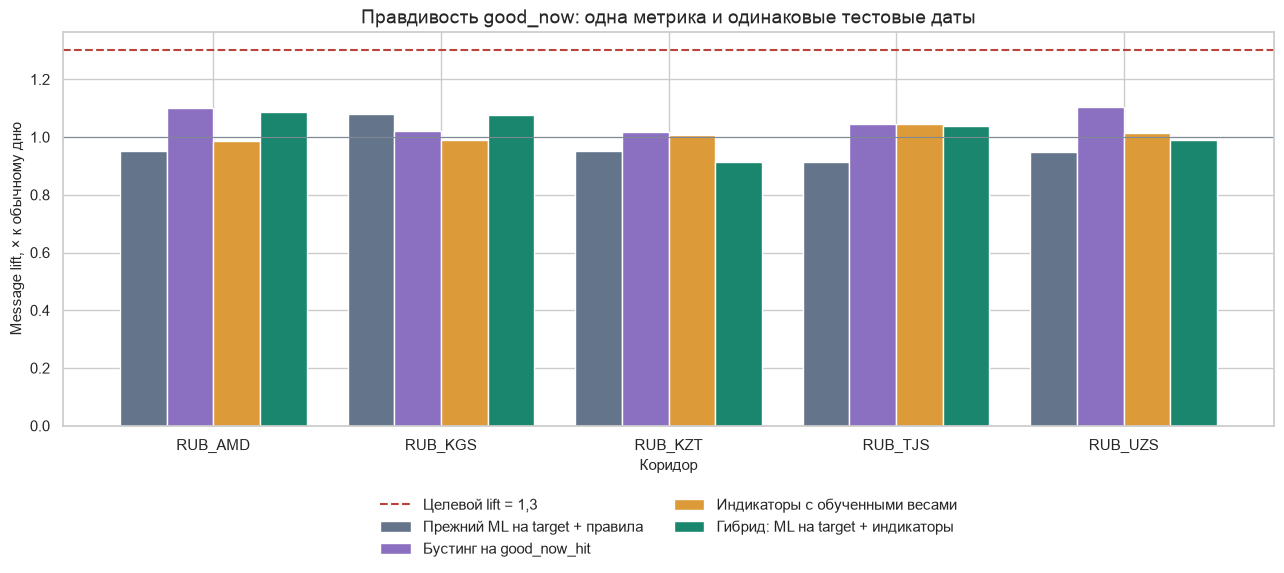

In [30]:
fig_hybrid_comparison, ax = plt.subplots(figsize=(13, 6))
hybrid_lift_table.rename(columns=HYBRID_NAMES).plot.bar(
    ax=ax, color=["#64748b", "#8b6fc0", "#dc9a38", "#19866d"], width=0.82,
)
ax.axhline(1.3, color="#ba443b", linestyle="--", linewidth=1.5, label="Целевой lift = 1,3")
ax.axhline(1.0, color="#7e8995", linewidth=0.8)
ax.set_title("Правдивость good_now: одна метрика и одинаковые тестовые даты")
ax.set_xlabel("Коридор")
ax.set_ylabel("Message lift, × к обычному дню")
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)
fig_hybrid_comparison.tight_layout()
plt.show()

## 21. Смотрим решения глазами

На следующем графике зелёные звёзды — сигнал, после которого подтвердился
`good_now_hit`. Красные треугольники — сигнал, после которого появился заметно
более выгодный курс. Жёлтые точки — `good_now_hit = 1`, но сигнала нет.
Это **другая разметка**, чем звёзды `target` на старом графике.

Период выбран заранее: январь 2024, RUB→TJS. Не заменяем его более красивым месяцем.

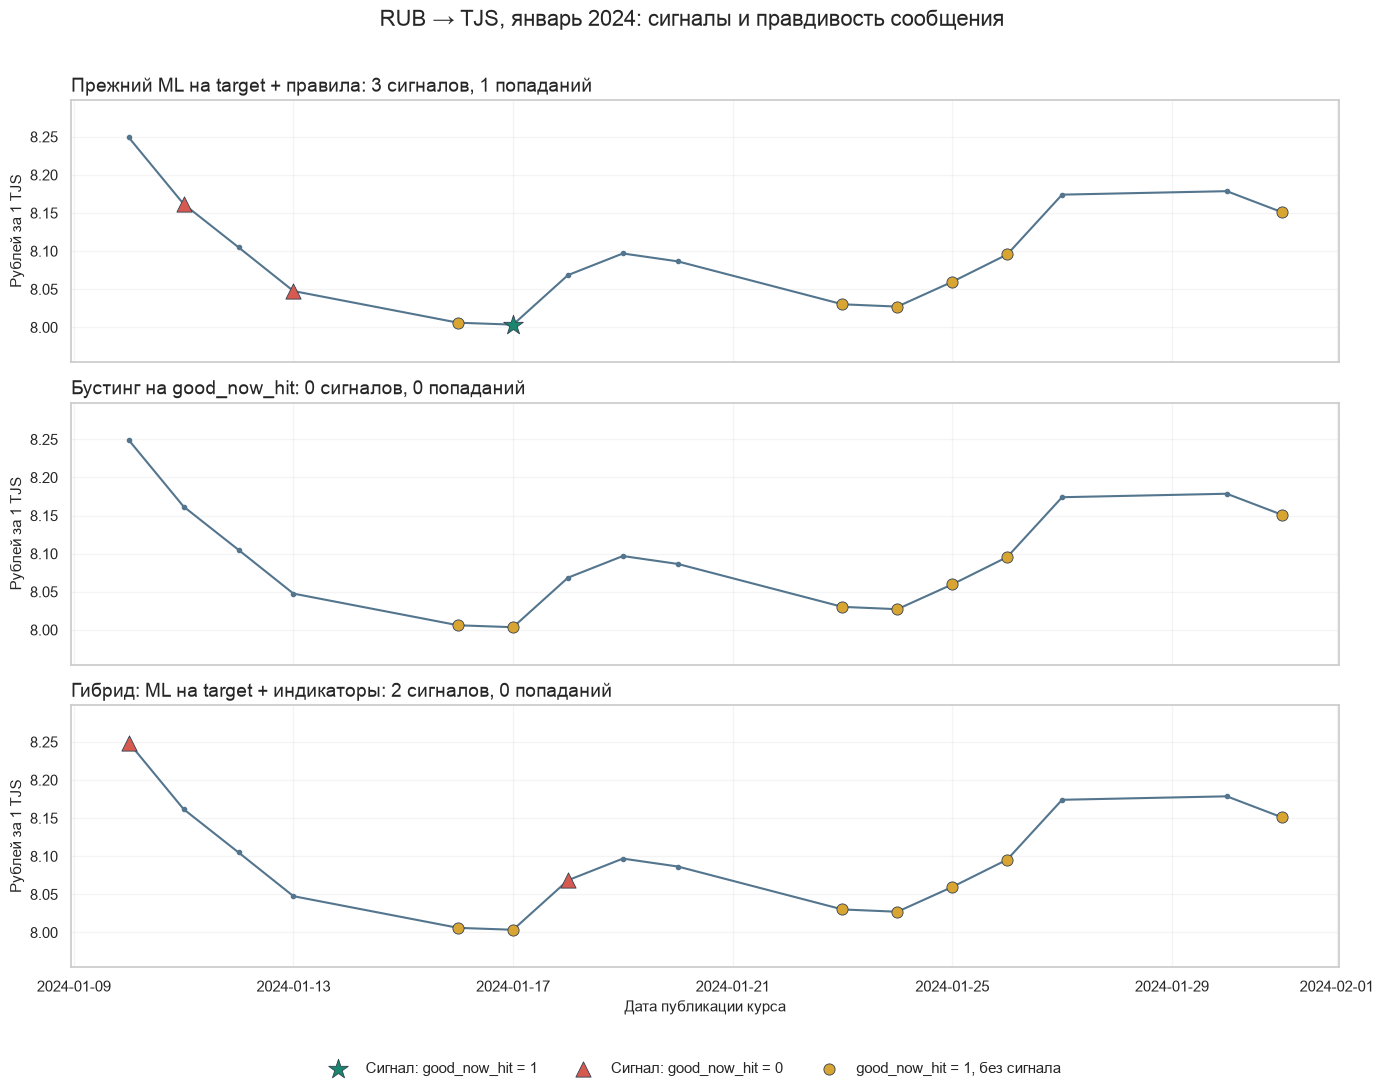

In [31]:
chart_corridor = "RUB_TJS"
chart_start = pd.Timestamp("2024-01-01")
chart_end = chart_start + pd.DateOffset(months=1)
chart_variants = ("legacy_target", "ml_good_now", "hybrid")
fig_hybrid_signals, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True, sharey=True)
for ax, variant in zip(axes, chart_variants):
    frame = hybrid_daily.loc[
        hybrid_daily.corridor.eq(chart_corridor) & hybrid_daily.variant.eq(variant)
        & hybrid_daily.available_date.ge(chart_start) & hybrid_daily.available_date.lt(chart_end)
    ].copy()
    truth = frame.good_now_hit.astype(bool)
    ax.plot(frame.available_date, frame.rub_per_unit, color="#53758d", marker="o", markersize=3)
    for mask, marker, color, size, label in [
        (frame.signal & truth, "*", "#19866d", 220, "Сигнал: good_now_hit = 1"),
        (frame.signal & ~truth, "^", "#d75a50", 120, "Сигнал: good_now_hit = 0"),
        (~frame.signal & truth, "o", "#d9a532", 65, "good_now_hit = 1, без сигнала"),
    ]:
        selected = frame.loc[mask]
        ax.scatter(selected.available_date, selected.rub_per_unit, marker=marker,
                   color=color, s=size, edgecolor="#304050", linewidth=0.6, zorder=5, label=label)
    hits = int((frame.signal & truth).sum())
    ax.set_title(f"{HYBRID_NAMES[variant]}: {int(frame.signal.sum())} сигналов, {hits} попаданий", loc="left")
    ax.set_ylabel("Рублей за 1 TJS")
    ax.margins(y=0.20)
    ax.grid(alpha=0.2)
handles, labels = axes[0].get_legend_handles_labels()
fig_hybrid_signals.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
axes[-1].set_xlabel("Дата публикации курса")
fig_hybrid_signals.suptitle("RUB → TJS, январь 2024: сигналы и правдивость сообщения", fontsize=16)
fig_hybrid_signals.tight_layout(rect=(0, 0.05, 1, 0.97))
plt.show()

## 22. Расчёт на выбранную дату с памятью об отправках

В старой финальной функции были только кандидаты, без сохранения паузы.
**У нового гибрида бэктест и replay используют одну функцию `hybrid_send_policy`.**
Replay восстанавливает решения по порядку от фиксированного старта, переобучает
модели каждые 125 публикаций и помнит отправки через границы блоков.

Это медленный проверочный режим. В сервисе модель и состояние нужно хранить,
обновляя их по расписанию и при каждой новой публикации. Если на календарную дату
нового курса нет, последний результат относится к последней публикации; повторно
отправлять его нельзя. Реальной рассылки в ноутбуке нет.

Последние даты не имеют известных меток, но их оценки и решения всё равно считаются:
неизвестный `target` сегодняшнего дня не используется при выборе сигнала.

In [32]:
hybrid_demo_date = demo_date
hybrid_live_history = hybrid_replay_as_of(rates, "RUB_TJS", hybrid_demo_date)
display(Markdown(f"### Последние решения на срезе {hybrid_demo_date:%d.%m.%Y}"))
display(hybrid_live_history.tail(10))
display(Markdown("### Последняя публикация: отправить или пропустить"))
display(hybrid_live_history.tail(1))

### Последние решения на срезе 21.08.2026

,available_date,rub_per_unit,rule_level,rule_momentum,rule_stability,rule_reversal,corridor,score,threshold,signal,decision_reason,recommended_scenario,explanation,active_indicators
3229,2026-08-08,8.88517,False,False,False,False,RUB_TJS,0.462936,0.470171,False,below_threshold,good_now,За пять публикаций курс вырос на 3.41%,
3230,2026-08-11,8.92710,False,False,False,False,RUB_TJS,0.462936,0.470171,False,below_threshold,good_now,За пять публикаций курс вырос на 3.11%,
3231,2026-08-12,8.90205,False,False,False,False,RUB_TJS,0.466114,0.470171,False,below_threshold,good_now,За пять публикаций курс вырос на 1.50%,
3232,2026-08-13,8.96991,False,False,False,False,RUB_TJS,0.462936,0.470171,False,below_threshold,good_now,За пять публикаций курс вырос на 2.38%,
3233,2026-08-14,9.04757,False,False,False,False,RUB_TJS,0.462936,0.470171,False,below_threshold,good_now,За пять публикаций курс вырос на 2.78%,
3234,2026-08-15,9.12736,False,False,False,False,RUB_TJS,0.462936,0.470171,False,below_threshold,good_now,За пять публикаций курс вырос на 2.73%,
3235,2026-08-18,9.18143,False,False,False,False,RUB_TJS,0.462936,0.470171,False,below_threshold,good_now,За пять публикаций курс вырос на 2.85%,
3236,2026-08-19,9.19991,False,False,False,False,RUB_TJS,0.466114,0.470171,False,below_threshold,good_now,За пять публикаций курс вырос на 3.35%,
3237,2026-08-20,9.19611,False,False,False,False,RUB_TJS,0.466114,0.470171,False,below_threshold,good_now,За пять публикаций курс вырос на 2.52%,
3238,2026-08-21,9.00931,False,False,False,False,RUB_TJS,0.597904,0.470171,True,send,good_now,За пять публикаций курс снизился на 0.42%,


### Последняя публикация: отправить или пропустить

,available_date,rub_per_unit,rule_level,rule_momentum,rule_stability,rule_reversal,corridor,score,threshold,signal,decision_reason,recommended_scenario,explanation,active_indicators
3238,2026-08-21,9.00931,False,False,False,False,RUB_TJS,0.597904,0.470171,True,send,good_now,За пять публикаций курс снизился на 0.42%,


## 23. Проверяем, что гибрид не подсматривает ответы

Проверки ниже подтверждают границы обучения, одинаковые тестовые даты, совпадение
исходного baseline и новый лимит отправок. Отдельно инвертируем тестовые метки:
оценки и пороги не должны измениться. Сравниваем replay с физически обрезанным
файлом и с соответствующей частью первого тестового блока.

In [33]:
assert (hybrid_audit.base_fit_last < hybrid_audit.meta_first).all()
assert (hybrid_audit.meta_last < hybrid_audit.validation_first).all()
assert (hybrid_audit.labels_observed_through < hybrid_audit.test_first).all()
for corridor, group in hybrid_daily.groupby("corridor"):
    expected = group.loc[group.variant.eq("legacy_target"), "available_date"].to_numpy()
    for variant in HYBRID_VARIANTS:
        np.testing.assert_array_equal(expected, group.loc[group.variant.eq(variant), "available_date"].to_numpy())
    original = summary.loc[summary.corridor.eq(corridor) & summary.model.eq("hist_gradient_boosting")].iloc[0]
    reproduced = hybrid_summary.loc[hybrid_summary.corridor.eq(corridor) & hybrid_summary.variant.eq("legacy_target")].iloc[0]
    assert int(original.signals) == int(reproduced.signals)
    np.testing.assert_allclose(original.message_lift, reproduced.message_lift, rtol=1e-10)
    for variant in ("ml_good_now", "rules_only", "hybrid"):
        sent_dates = group.loc[group.variant.eq(variant) & group.signal, "available_date"].sort_values()
        for date in sent_dates:
            assert ((sent_dates > date - pd.Timedelta(days=7)) & (sent_dates <= date)).sum() <= 2

check_dataset = hybrid_datasets["RUB_TJS"].iloc[:875].copy()
check_bundle = hybrid_fit_fold(check_dataset, 750)
changed = check_dataset.copy()
for column in ("target", "good_now_hit"):
    changed.loc[750:, column] = 1 - changed.loc[750:, column].astype(int)
changed_bundle = hybrid_fit_fold(changed, 750)
assert check_bundle["thresholds"] == changed_bundle["thresholds"]
original_scores = hybrid_predict(check_bundle, check_dataset.iloc[750:])
changed_scores = hybrid_predict(changed_bundle, changed.iloc[750:])
for variant in HYBRID_VARIANTS:
    np.testing.assert_allclose(original_scores[variant], changed_scores[variant], rtol=0, atol=0)

replay_cutoff = check_dataset.available_date.iloc[780]
replay_full = hybrid_replay_as_of(rates, "RUB_TJS", replay_cutoff)
replay_cut = hybrid_replay_as_of(rates.loc[rates.available_date <= replay_cutoff], "RUB_TJS", replay_cutoff)
pd.testing.assert_frame_equal(replay_full, replay_cut)
replay_expected = hybrid_daily.loc[
    hybrid_daily.corridor.eq("RUB_TJS") & hybrid_daily.variant.eq("hybrid")
    & hybrid_daily.available_date.le(replay_cutoff)
]
np.testing.assert_array_equal(replay_full.signal, replay_expected.signal)
np.testing.assert_allclose(replay_full.score, replay_expected.score, rtol=0, atol=0)
print("✅ Гибрид: проверки тестовых меток, as_of, состояния, лимита и старого baseline пройдены")

✅ Гибрид: проверки тестовых меток, as_of, состояния, лимита и старого baseline пройдены


## 24. Честный вывод и сохранение результатов

Новое название слоя само по себе не улучшает продукт. Сначала смотрим,
насколько изменился `message_lift`, затем — не потеряли ли частоту и устойчивость.
Если гибрид выигрывает у старого target-бустинга, но не выигрывает у прямого
обучения на `good_now_hit` или у индикаторов, это тоже важный результат:
дополнительная сложность ещё не обоснована.

Пять последних фолдов уже присутствовали в предыдущих исследованиях, поэтому
не называем их новым нетронутым holdout. Для окончательного выбора нужен
замороженный протокол и следующий период наблюдений.

In [34]:
hybrid_result = hybrid_summary.loc[hybrid_summary.variant.eq("hybrid")].copy()
good_lift_count = int(hybrid_result.message_lift.ge(1.3).sum())
mean_frequency_count = int(hybrid_result.signals_per_week.between(1, 2).sum())
uniform_count = int(hybrid_result.weeks_with_1_2_share.ge(0.90).sum())
display(Markdown(
    f"**Итог:** message_lift гибрида {hybrid_result.message_lift.min():.3f}–"
    f"{hybrid_result.message_lift.max():.3f}. Порог 1,3 достигнут на {good_lift_count}/5 коридорах. "
    f"Средняя частота 1–2 в неделю — на {mean_frequency_count}/5. "
    f"Не менее 90% недель с 1–2 сигналами — на {uniform_count}/5. "
    "Это отдельные проверки, а не автоматическое заявление, что кейс закрыт."
))

hybrid_output_dir = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd() / "reports" / "hybrid"
hybrid_output_dir.mkdir(parents=True, exist_ok=True)
for name, table in [
    ("summary", hybrid_summary), ("daily_decisions", hybrid_daily),
    ("training_audit", hybrid_audit), ("expert_weights", hybrid_weight_history),
    ("bootstrap_vs_direct", hybrid_vs_direct), ("bootstrap_vs_rules", hybrid_vs_rules),
    ("recent_summary", hybrid_recent_summary),
]:
    table.to_json(hybrid_output_dir / f"hybrid_{name}.json", orient="records", date_format="iso", indent=2)
fig_hybrid_comparison.savefig(hybrid_output_dir / "hybrid-message-lift.png", dpi=160, bbox_inches="tight")
fig_hybrid_signals.savefig(hybrid_output_dir / "hybrid-signals-january-2024.png", dpi=160, bbox_inches="tight")
print("Результаты сохранены:", hybrid_output_dir)

**Итог:** message_lift гибрида 0.912–1.086. Порог 1,3 достигнут на 0/5 коридорах. Средняя частота 1–2 в неделю — на 2/5. Не менее 90% недель с 1–2 сигналами — на 0/5. Это отдельные проверки, а не автоматическое заявление, что кейс закрыт.

Результаты сохранены: /Users/aleksandr/PycharmProjects/huck/reports/hybrid
